# Clase 04 - Aprendizaje supervisado y Random Forest geoespacial

**Fecha:** 2026-09-21 · **Docente:** Fabian Cetina

## Objetivos
- Preparar 17 predictores y observaciones sin alterar entradas.
- Entrenar e interpretar ajuste, validación, importancia y residuales.


Esta práctica estudia la biomasa de Coiba con la geodatabase `99 - Recursos/datos/clase_04/Datos_Coiba.gdb`, priorizando herramientas de **ArcPy / ArcGIS Pro** para inventario, reproyección, extracción de valores raster, entrenamiento forest-based y diagnóstico. Pandas y Matplotlib se usan solo como capa de presentación para tablas y gráficos dentro del notebook.

El objetivo es entrenar un modelo **Forest-based / Random Forest** para estimar `AGBD` —biomasa aérea— a partir de puntos de observación y rasters explicativos de Coiba: bandas Landsat, índices espectrales y variables topográficas.

La lógica de trabajo es:

1. inventariar la geodatabase;
2. revisar puntos de biomasa y rasters;
3. proyectar los puntos al sistema de los rasters principales;
4. extraer valores raster sobre cada punto;
5. entrenar un modelo forest-based de regresión;
6. revisar métricas, residuales e importancia de variables;
7. guardar tablas y gráficos limpios en `99 - Recursos/salidas_clase_04/practica_01/`.

> Nota: el notebook no modifica la geodatabase fuente. Todas las salidas se escriben en una carpeta y geodatabase de trabajo.


## Referencias usadas en la práctica

- Esri ArcGIS Pro. *Forest-based and Boosted Classification and Regression*. <https://pro.arcgis.com/en/pro-app/latest/tool-reference/spatial-statistics/forestbasedclassificationregression.htm>
- Esri ArcGIS Pro. *How Forest-based and Boosted Classification and Regression works*. <https://pro.arcgis.com/en/pro-app/latest/tool-reference/spatial-statistics/how-forest-works.htm>
- Esri ArcGIS Pro. *Extract Multi Values to Points*. <https://pro.arcgis.com/en/pro-app/latest/tool-reference/spatial-analyst/extract-multi-values-to-points.htm>
- Esri ArcGIS Pro. *Evaluate Predictions with Cross-validation*. <https://pro.arcgis.com/en/pro-app/latest/tool-reference/spatial-statistics/evaluate-predictions-with-cross-validation.htm>
- Breiman, L. (2001). *Random Forests*. <https://doi.org/10.1023/A:1010933404324>
- Rouse et al. (1974). *Monitoring vegetation systems in the Great Plains with ERTS*. <https://ntrs.nasa.gov/citations/19740022614>


## 1. Preparar entorno y rutas

La primera celda localiza la raíz del vault desde el directorio actual y define únicamente las rutas. `DATA_DIR` usa la copia pública `clase_04`, con valores idénticos y metadatos privados filtrados; `OUTPUT_DIR` dirige resultados nuevos a Clase 04. Las salidas guardadas conservan la ruta histórica `clase_06`: no representan una ejecución nueva sobre la copia pública. Puede cambiar ambas por rutas externas, manteniendo entradas y salidas separadas. Todavía no importa ArcPy ni crea archivos.

Requisitos: ArcGIS Pro 3.6, licencia local disponible y extensión Spatial Analyst. No se instalan componentes ni se inicia sesión. Configure entradas y salidas externas en la primera celda; el resto usa esas rutas. Cada ejecución produce una carpeta UUID, una GDB y un APRX nuevos. Los auxiliares siguientes exportan gráficos y mapas nativos sin depender de otro notebook.


In [1]:
# Etapa de la práctica: entradas intactas; resultados en la carpeta de ejecución.
# Cambie estas dos rutas por rutas externas si necesita otros directorios.
from pathlib import Path
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / '99 - Recursos').is_dir())
DATA_DIR = ROOT / '99 - Recursos/datos/clase_04'
OUTPUT_DIR = ROOT / '99 - Recursos/salidas_clase_04/practica_01'


Las rutas quedan en memoria; la ausencia de una tabla es esperada. Si no se encuentra la carpeta `99 - Recursos`, revise el directorio de inicio antes de continuar: definir una ruta no demuestra que exista la GDB ni que haya licencia.

### Entorno aislado y utilidades tabulares

Con las rutas anteriores, la siguiente celda importa bibliotecas, exige Pro 3.6 y Spatial Analyst, comprueba la GDB y crea `ejecucion_<uuid>/clase_04_coiba_rf.gdb` con sobrescritura desactivada. `table_to_df` leerá campos mediante cursor; `forest_messages_to_html` presentará mensajes, sin calcular métricas nuevas.


In [2]:
# Etapa de la práctica: entradas intactas; resultados en la carpeta de ejecución.
from pathlib import Path
import math
import re

import arcpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image, HTML

# Cada ejecución crea una carpeta nueva; jamás sobrescribe resultados anteriores.
import uuid
info = arcpy.GetInstallInfo()
print('ArcGIS Pro', info['Version'], 'licencia', arcpy.ProductInfo())
if not info['Version'].startswith('3.6'):
    raise RuntimeError('Se requiere ArcGIS Pro 3.6: revisar compatibilidad.')
if arcpy.ProductInfo() in ('NotInitialized', 'Unavailable'):
    raise RuntimeError('Licencia local no disponible.')
if arcpy.CheckExtension('Spatial') != 'Available':
    raise RuntimeError('Spatial Analyst no disponible.')
arcpy.CheckOutExtension('Spatial')
SOURCE_GDB = DATA_DIR / 'Datos_Coiba.gdb'
if not arcpy.Exists(str(SOURCE_GDB)):
    raise FileNotFoundError(SOURCE_GDB)
if OUTPUT_DIR.resolve().is_relative_to(DATA_DIR.resolve()):
    raise ValueError('Las salidas deben estar fuera de las entradas.')
OUT = OUTPUT_DIR / ('ejecucion_' + uuid.uuid4().hex)
OUT.mkdir(parents=True, exist_ok=False)
WORK_GDB = OUT / 'clase_04_coiba_rf.gdb'
arcpy.management.CreateFileGDB(str(OUT), WORK_GDB.name)
arcpy.env.overwriteOutput = False
arcpy.env.workspace = str(SOURCE_GDB)

def rel(path):
    path = Path(path)
    try:
        return path.relative_to(ROOT).as_posix()
    except ValueError:
        return str(path)

def table_to_df(table, fields):
    rows = []
    with arcpy.da.SearchCursor(str(table), fields) as cursor:
        for row in cursor:
            rows.append(dict(zip(fields, row)))
    return pd.DataFrame(rows)

print("Fuente:", rel(SOURCE_GDB))
print("Salidas:", rel(OUT))
print("GDB de trabajo:", rel(WORK_GDB))


def forest_messages_to_html(messages: str) -> str:
    """Convierte mensajes de arcpy.stats.Forest en una salida HTML legible para el notebook."""
    import html
    lines = [line.rstrip() for line in messages.splitlines() if line.strip()]
    blocks = []
    current_title = "Diagnóstico de ArcPy"
    current = []
    for line in lines:
        stripped = line.strip()
        if stripped.startswith("---") and stripped.endswith("---"):
            if current:
                blocks.append((current_title, current))
                current = []
            current_title = stripped.strip("- ") or current_title
        elif stripped.startswith("Start Time") or stripped.startswith("Succeeded") or stripped.startswith("End Time"):
            continue
        else:
            current.append(stripped)
    if current:
        blocks.append((current_title, current))

    css = """
    <style>
      .arcgis-report{font-family:Segoe UI,Arial,sans-serif;line-height:1.35;color:#223;}
      .arcgis-report h3{margin:1em 0 .35em;color:#1f4e79;border-bottom:1px solid #bdd7ee;padding-bottom:.2em;}
      .arcgis-report pre{background:#fbfbf8;border:1px solid #ddd;border-radius:8px;padding:10px;white-space:pre-wrap;font-size:12px;}
      .arcgis-report .note{background:#fff3e0;border-left:4px solid #f28e2b;padding:8px 10px;margin:10px 0;}
    </style>
    """
    body = [css, '<div class="arcgis-report">', '<h2>Salida de ArcPy: Forest-based Regression</h2>']
    body.append('<div class="note"><strong>Lectura:</strong> esta salida corresponde a la herramienta de ArcGIS Pro. Debe interpretarse junto con residuales, mapa de errores e importancia de variables; no es una validación espacial final.</div>')
    for title, content in blocks:
        body.append(f"<h3>{html.escape(title.title())}</h3>")
        body.append("<pre>" + html.escape("\n".join(content)) + "</pre>")
    body.append('</div>')
    return "\n".join(body)


ArcGIS Pro 3.6.2 licencia ArcInfo


Fuente: 99 - Recursos/datos/clase_06/Datos_Coiba.gdb
Salidas: 99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81
GDB de trabajo: 99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/clase_04_coiba_rf.gdb


Compruebe versión, licencia y las tres rutas impresas: fuente, carpeta UUID y GDB de trabajo deben ser coherentes, y ninguna salida debe estar dentro de las entradas. Crear la GDB confirma un destino de escritura, no un entrenamiento. Un error de licencia detiene lo dependiente; no se corrige cambiando datos.

### Preparar mapas y gráficos autónomos

La siguiente celda requiere la plantilla local `Blank.aprx` y `WORK_GDB`. Guarda un APRX nuevo y define auxiliares: gráficos de 1500 × 950 píxeles, mapas con leyenda/CRS y exportación a 160 dpi. Para RESIDUAL verifica observado menos predicho y crea capas por signo con consultas SQL y SimpleRenderer público; para otros campos usa cinco clases graduadas. No se calculan predicciones aquí.


In [3]:
# Auxiliares autónomos ArcGIS: proyecto nuevo, mapas locales y exportaciones nativas.
template = Path(arcpy.GetInstallInfo()['InstallDir']) / 'Resources/ArcToolBox/Services/routingservices/data/Blank.aprx'
if not template.is_file():
    raise FileNotFoundError('Falta la plantilla local Blank.aprx.')
aprx_path = OUT / 'coiba_resultados.aprx'
seed = arcpy.mp.ArcGISProject(str(template))
seed.saveACopy(str(aprx_path))
del seed
project = arcpy.mp.ArcGISProject(str(aprx_path))
project.defaultGeodatabase = str(WORK_GDB)
def rect(x0,y0,x1,y1):
    return arcpy.Polygon(arcpy.Array([arcpy.Point(x0,y0),arcpy.Point(x1,y0),arcpy.Point(x1,y1),arcpy.Point(x0,y1)]))
def native_chart(chart, name):
    chart.theme = 'Light'
    png = OUT / (name + '.png')
    chart.exportToPNG(str(png), 1500, 950)
    display(Image(filename=str(png), width=1000))
def native_map(fc, name, field, units):
    # Solo capas de trabajo: nada se guarda en la entrada.
    if not Path(fc).resolve().is_relative_to(OUT.resolve()):
        raise ValueError('El mapa requiere una copia de trabajo.')
    sr = arcpy.Describe(str(fc)).spatialReference
    m = project.createMap(name, 'MAP')
    for layer in m.listLayers():
        m.removeLayer(layer)
    m.spatialReference = sr
    layer = m.addDataFromPath(str(fc))
    layer.name = field + ' (' + units + ')'
    if field == 'RESIDUAL':
        import math
        # Verificar el signo real antes de asignar etiquetas de error.
        with arcpy.da.SearchCursor(str(fc), ['AGBD', 'PREDICTED', field]) as rows:
            if not all(o is not None and p is not None and r is not None and math.isclose(o - p, r, rel_tol=1e-9, abs_tol=1e-7) for o, p, r in rows):
                raise RuntimeError('RESIDUAL no coincide con observado menos predicho.')
        # Solo valores finitos con XY dibujable; los conteos impiden omisiones.
        with arcpy.da.SearchCursor(layer, [field, 'SHAPE@XY']) as rows:
            visible_points = [(float(v), xy) for v, xy in rows
                              if v is not None and math.isfinite(v) and xy
                              and all(c is not None and math.isfinite(c) for c in xy)]
        if not visible_points:
            raise RuntimeError('RESIDUAL: no hay puntos con valor y coordenadas finitos.')
        values = [v for v, xy in visible_points]
        groups = [([v for v in values if v < 0], 'Sobrepredicción (< 0)', [33, 102, 172, 100]),
                  ([v for v in values if v == 0], 'Sin error (= 0)', [100, 100, 100, 100]),
                  ([v for v in values if v > 0], 'Subpredicción (> 0)', [178, 24, 43, 100])]
        sign_layers = []
        full_extent = arcpy.Describe(str(fc)).extent
        m.removeLayer(layer)
        for observed, label, color in groups:
            if not observed:
                continue
            # Cada signo usa la misma copia y un símbolo puntual público, sin CIM.
            layer = m.addDataFromPath(str(fc))
            operator = '<' if max(observed) < 0 else ('>' if min(observed) > 0 else '=')
            layer.definitionQuery = arcpy.AddFieldDelimiters(str(fc), field) + ' ' + operator + ' 0'
            layer.name = f'{label}: n={len(observed)}'
            layer.visible = True
            layer.minThreshold = layer.maxThreshold = 0
            sym = layer.symbology
            sym.updateRenderer('SimpleRenderer')
            sym.renderer.symbol.color = {'RGB': color}
            sym.renderer.symbol.size = 4
            layer.symbology = sym
            actual_count = int(arcpy.management.GetCount(layer)[0])
            if actual_count != len(observed) or layer.symbology.renderer.type != 'SimpleRenderer':
                raise RuntimeError('RESIDUAL: signo, conteo o símbolo no conservados.')
            sign_layers.append(layer)
        if sum(int(arcpy.management.GetCount(item)[0]) for item in sign_layers) != int(arcpy.management.GetCount(str(fc))[0]):
            raise RuntimeError('RESIDUAL: entidades ausentes en las capas por signo.')
    else:
        sym = layer.symbology
        sym.updateRenderer('GraduatedColorsRenderer')
        sym.renderer.classificationField = field
        sym.renderer.breakCount = 5
        layer.symbology = sym
    layout = project.createLayout(14,10,'INCH',name)
    frame = layout.createMapFrame(rect(.4,1.2,9.7,8.7),m,'Mapa')
    frame.camera.setExtent(full_extent if field == 'RESIDUAL' else frame.getLayerExtent(layer,False,True))
    frame.camera.scale *= 1.15
    legend = layout.createMapSurroundElement(rect(10,1.3,13.7,8.6),'LEGEND',frame,None,'Leyenda')
    legend.fittingStrategy = 'AdjustFontSize'
    project.createTextElement(layout,arcpy.Point(.4,9.2),'POINT',field + ' (' + units + ')',16,'Segoe UI','Regular')
    coord_units = sr.linearUnitName if sr.type == 'Projected' else sr.angularUnitName
    footer = f'N arriba | escala 1:{frame.camera.scale:,.0f} | {sr.name} | {coord_units}'
    project.createTextElement(layout,arcpy.Point(.4,.75),'POINT',footer,9,'Segoe UI','Regular')
    if field == 'RESIDUAL':
        # Verificar todos los XY y las restricciones efectivas, no solo la leyenda.
        extent = frame.camera.getExtent()
        if any(not item.visible or item.minThreshold or item.maxThreshold for item in sign_layers):
            raise RuntimeError('RESIDUAL: visibilidad o escala restringen los puntos.')
        if not all(extent.XMin <= x <= extent.XMax and extent.YMin <= y <= extent.YMax
                   for value, (x, y) in visible_points):
            raise RuntimeError('RESIDUAL: puntos fuera del marco.')
        detail = f'Observado - predicho | rango {min(values):.3f} a {max(values):.3f} {units} | cero: {sum(v == 0 for v in values)}'
        project.createTextElement(layout,arcpy.Point(.4,.35),'POINT',detail,10,'Segoe UI','Regular')
    project.save()
    png = OUT / (name + '.png')
    layout.exportToPNG(str(png),resolution=160)
    display(Image(filename=str(png),width=1000))


El efecto de los auxiliares es disponer de un proyecto independiente y funciones reutilizables; sus cuerpos dibujarán cuando sean llamados. Tener un renderer o un APRX no acredita un mapa legible: habrá que inspeccionar cada PNG. Si falta la plantilla, no se sustituye por un proyecto personal.

## 2. Inventariar la geodatabase

Desde `SOURCE_GDB`, ListFeatureClasses/ListRasters y Describe identifican nombres, geometrías y CRS; Get Count cuenta entidades, no píxeles. La tabla ordenada se guarda como `clase_04_inventario_gdb.csv` en OUT. Esta lectura no altera datos ni asigna un CRS supuesto.


In [4]:
# Etapa de la práctica: entradas intactas; resultados en la carpeta de ejecución.
arcpy.env.workspace = str(SOURCE_GDB)

inventory = []
for fc in arcpy.ListFeatureClasses() or []:
    desc = arcpy.Describe(fc)
    inventory.append({
        "tipo": "Feature class",
        "nombre": fc,
        "geometría": desc.shapeType,
        "registros": int(arcpy.management.GetCount(fc)[0]),
        "sistema": desc.spatialReference.name,
    })

for raster in arcpy.ListRasters() or []:
    desc = arcpy.Describe(raster)
    inventory.append({
        "tipo": "Raster",
        "nombre": raster,
        "geometría": f"{desc.width} x {desc.height}",
        "registros": None,
        "sistema": desc.spatialReference.name,
    })

inventory_df = pd.DataFrame(inventory).sort_values(["tipo", "nombre"]).reset_index(drop=True)
display(inventory_df)
inventory_df.to_csv(OUT / "clase_04_inventario_gdb.csv", index=False, encoding="utf-8-sig")


,tipo,nombre,geometría,registros,sistema
0,Feature class,AGBD_Observaciones_2023_Coiba,Point,4946.0,GCS_WGS_1984
1,Feature class,Coiba,Polygon,1.0,WGS_1984_Web_Mercator_Auxiliary_Sphere
2,Raster,Aspect_DEM_30,1085 x 1198,NaN,GCS_WGS_1984
3,Raster,DEM_30_Mask,1085 x 1198,NaN,GCS_WGS_1984
4,Raster,DVI_Mask,1108 x 1227,NaN,WGS_1984_UTM_Zone_17N
5,Raster,EVI_Mask,1108 x 1227,NaN,WGS_1984_UTM_Zone_17N
6,Raster,LC09_20230222_B1_Mask,1108 x 1227,NaN,WGS_1984_UTM_Zone_17N
7,Raster,LC09_20230222_B2_Mask,1108 x 1227,NaN,WGS_1984_UTM_Zone_17N
8,Raster,LC09_20230222_B3_Mask,1108 x 1227,NaN,WGS_1984_UTM_Zone_17N
9,Raster,LC09_20230222_B4_Mask,1108 x 1227,NaN,WGS_1984_UTM_Zone_17N


En el inventario, distinga registros vectoriales de dimensiones raster: ancho × alto no es número de observaciones de campo. Un CRS conocido permite continuar la inspección, pero no prueba coincidencia de datum, cobertura o fecha. Use los nombres visibles para contrastar la selección siguiente.

## 3. Definir insumos de la práctica

`AGBD_Observaciones_2023_Coiba` aporta la respuesta `AGBD`. `RASTER_SPECS` vincula nombre fuente, campo extraído y significado de cada predictor: siete bandas, siete índices y tres variables topográficas. Esta especificación fija las 17 entradas del ejercicio; no selecciona automáticamente las mejores variables.


In [5]:
# Etapa de la práctica: entradas intactas; resultados en la carpeta de ejecución.
POINTS_FC = SOURCE_GDB / "AGBD_Observaciones_2023_Coiba"
TARGET_FIELD = "AGBD"

RASTER_SPECS = [
    ("LC09_20230222_B1_Mask", "B1", "Banda Landsat 9 - coastal/aerosol"),
    ("LC09_20230222_B2_Mask", "B2", "Banda Landsat 9 - azul"),
    ("LC09_20230222_B3_Mask", "B3", "Banda Landsat 9 - verde"),
    ("LC09_20230222_B4_Mask", "B4", "Banda Landsat 9 - rojo"),
    ("LC09_20230222_B5_Mask", "B5", "Banda Landsat 9 - infrarrojo cercano"),
    ("LC09_20230222_B6_Mask", "B6", "Banda Landsat 9 - SWIR 1"),
    ("LC09_20230222_B7_Mask", "B7", "Banda Landsat 9 - SWIR 2"),
    ("NDVI_Mask", "NDVI", "Índice de vegetación normalizado"),
    ("EVI_Mask", "EVI", "Índice de vegetación mejorado"),
    ("SAVI_Mask", "SAVI", "Índice de vegetación ajustado al suelo"),
    ("MNDWI_Mask", "MNDWI", "Índice de agua modificado"),
    ("MSI_Mask", "MSI", "Índice de estrés hídrico"),
    ("RVI_Mask", "RVI", "Ratio vegetation index"),
    ("DVI_Mask", "DVI", "Difference vegetation index"),
    ("DEM_30_Mask", "DEM", "Elevación"),
    ("Slope_DEM_30", "Slope", "Pendiente"),
    ("Aspect_DEM_30", "Aspect", "Aspecto"),
]

raster_df = pd.DataFrame(RASTER_SPECS, columns=["raster", "campo", "descripción"])
display(raster_df)


,raster,campo,descripción
0,LC09_20230222_B1_Mask,B1,Banda Landsat 9 - coastal/aerosol
1,LC09_20230222_B2_Mask,B2,Banda Landsat 9 - azul
2,LC09_20230222_B3_Mask,B3,Banda Landsat 9 - verde
3,LC09_20230222_B4_Mask,B4,Banda Landsat 9 - rojo
4,LC09_20230222_B5_Mask,B5,Banda Landsat 9 - infrarrojo cercano
5,LC09_20230222_B6_Mask,B6,Banda Landsat 9 - SWIR 1
6,LC09_20230222_B7_Mask,B7,Banda Landsat 9 - SWIR 2
7,NDVI_Mask,NDVI,Índice de vegetación normalizado
8,EVI_Mask,EVI,Índice de vegetación mejorado
9,SAVI_Mask,SAVI,Índice de vegetación ajustado al suelo


Lea la tabla como un diccionario de correspondencias: `NDVI_Mask` es un raster y `NDVI` será un campo de puntos, no son objetos intercambiables. Definir la lista no verifica todavía tipos, valores o existencia de cada raster. Los índices comparten bandas; 17 predictores no equivalen a 17 fuentes independientes.

## 4. Explorar la variable objetivo

Se leen `AGBD`, identificador y auxiliares disponibles (`lon`, `lat`, `Time`, `Trajectory`) sin exigir campos inexistentes. El diccionario, conteos de nulos/ceros y percentiles 5/25/50/75/95 describen la muestra. Copy Features crea `agbd_eda` para mapa e histograma nativos; el histograma Matplotlib de 40 intervalos conserva la presentación fuente.

El histograma nativo muestra frecuencia frente a AGBD; compare asimetría y extremos, sin confundir nulos con ceros. El mapa ArcGIS permite ver cobertura y concentración de observaciones: no es una superficie interpolada. La leyenda clasifica AGBD; el pie declara CRS y unidades de coordenadas. AGBD, MAE, RMSE y RESIDUAL se leen en Mg/ha por confirmación del usuario, no por metadatos ni prueba de origen GEDI. 1 Mg/ha equivale a 1 tonelada métrica por hectárea; no se convierten valores. Los rótulos genéricos de las imágenes históricas se conservan. Claves de trayectoria repetidas pueden representar varias observaciones del mismo recorrido, no duplicados a borrar.


Campos auxiliares ausentes: []


,campo,tipo,alias
0,OBJECTID,OID,OBJECTID
1,Shape,Geometry,Shape
2,lon,Double,lon
3,lat,Double,lat
4,Time,Date,Time
5,AGBD,Double,AGBD
6,Trajectory,Integer,Trajectory


Nulos: {'OBJECTID': 0, 'lon': 0, 'lat': 0, 'Time': 0, 'AGBD': 0, 'Trajectory': 0}


Ceros AGBD: 0
Time distintos: 3 repeticiones: 4943
Trajectory distintos: 24 repeticiones: 4922
CRS: GCS_WGS_1984


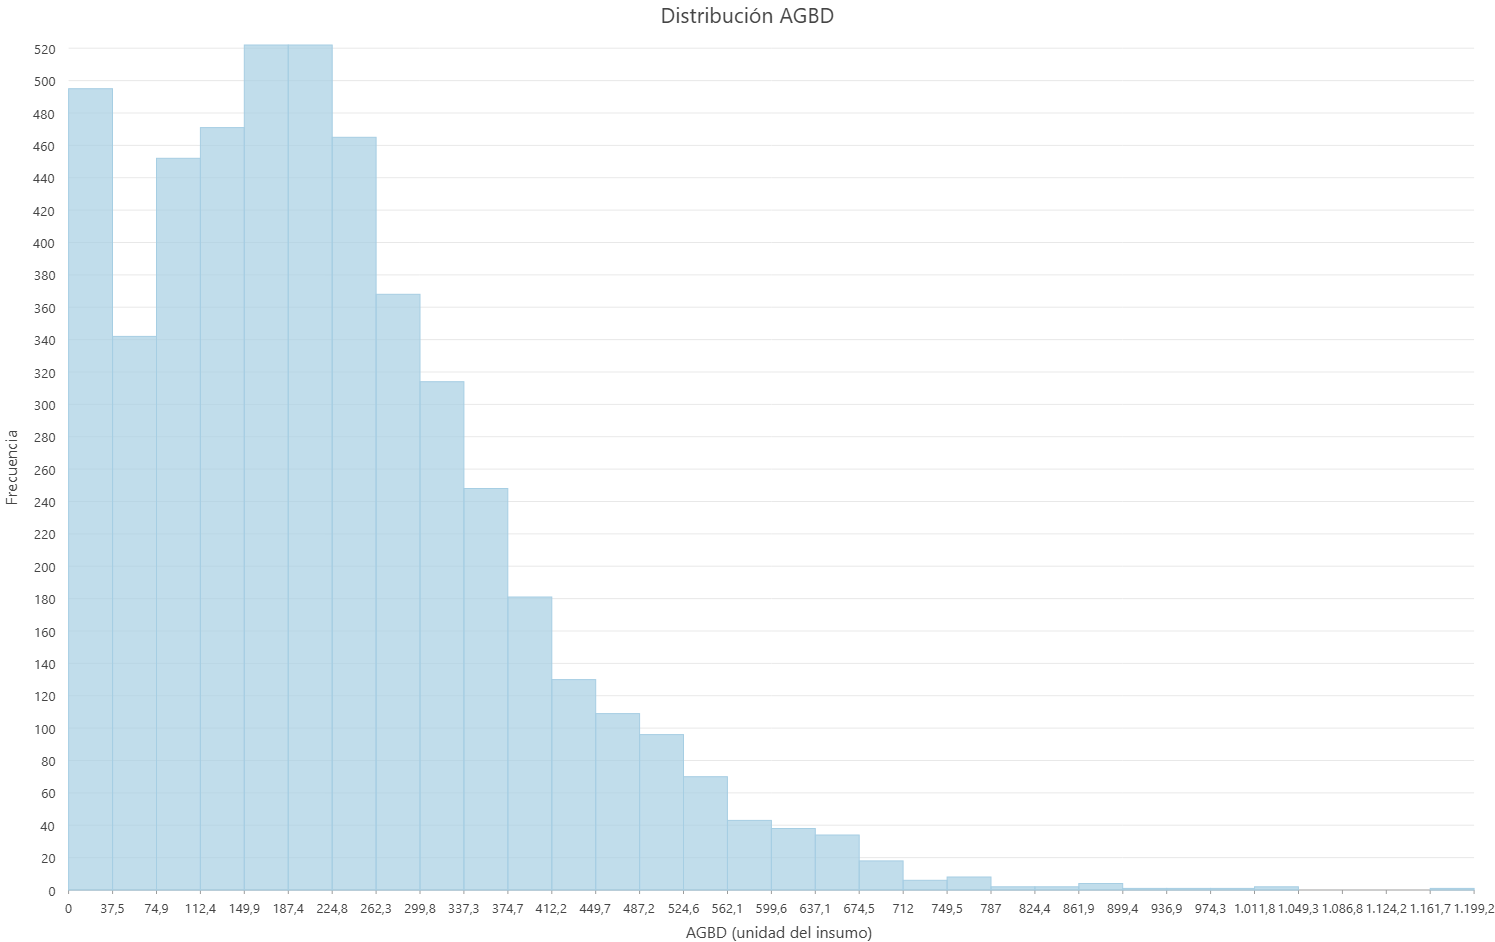

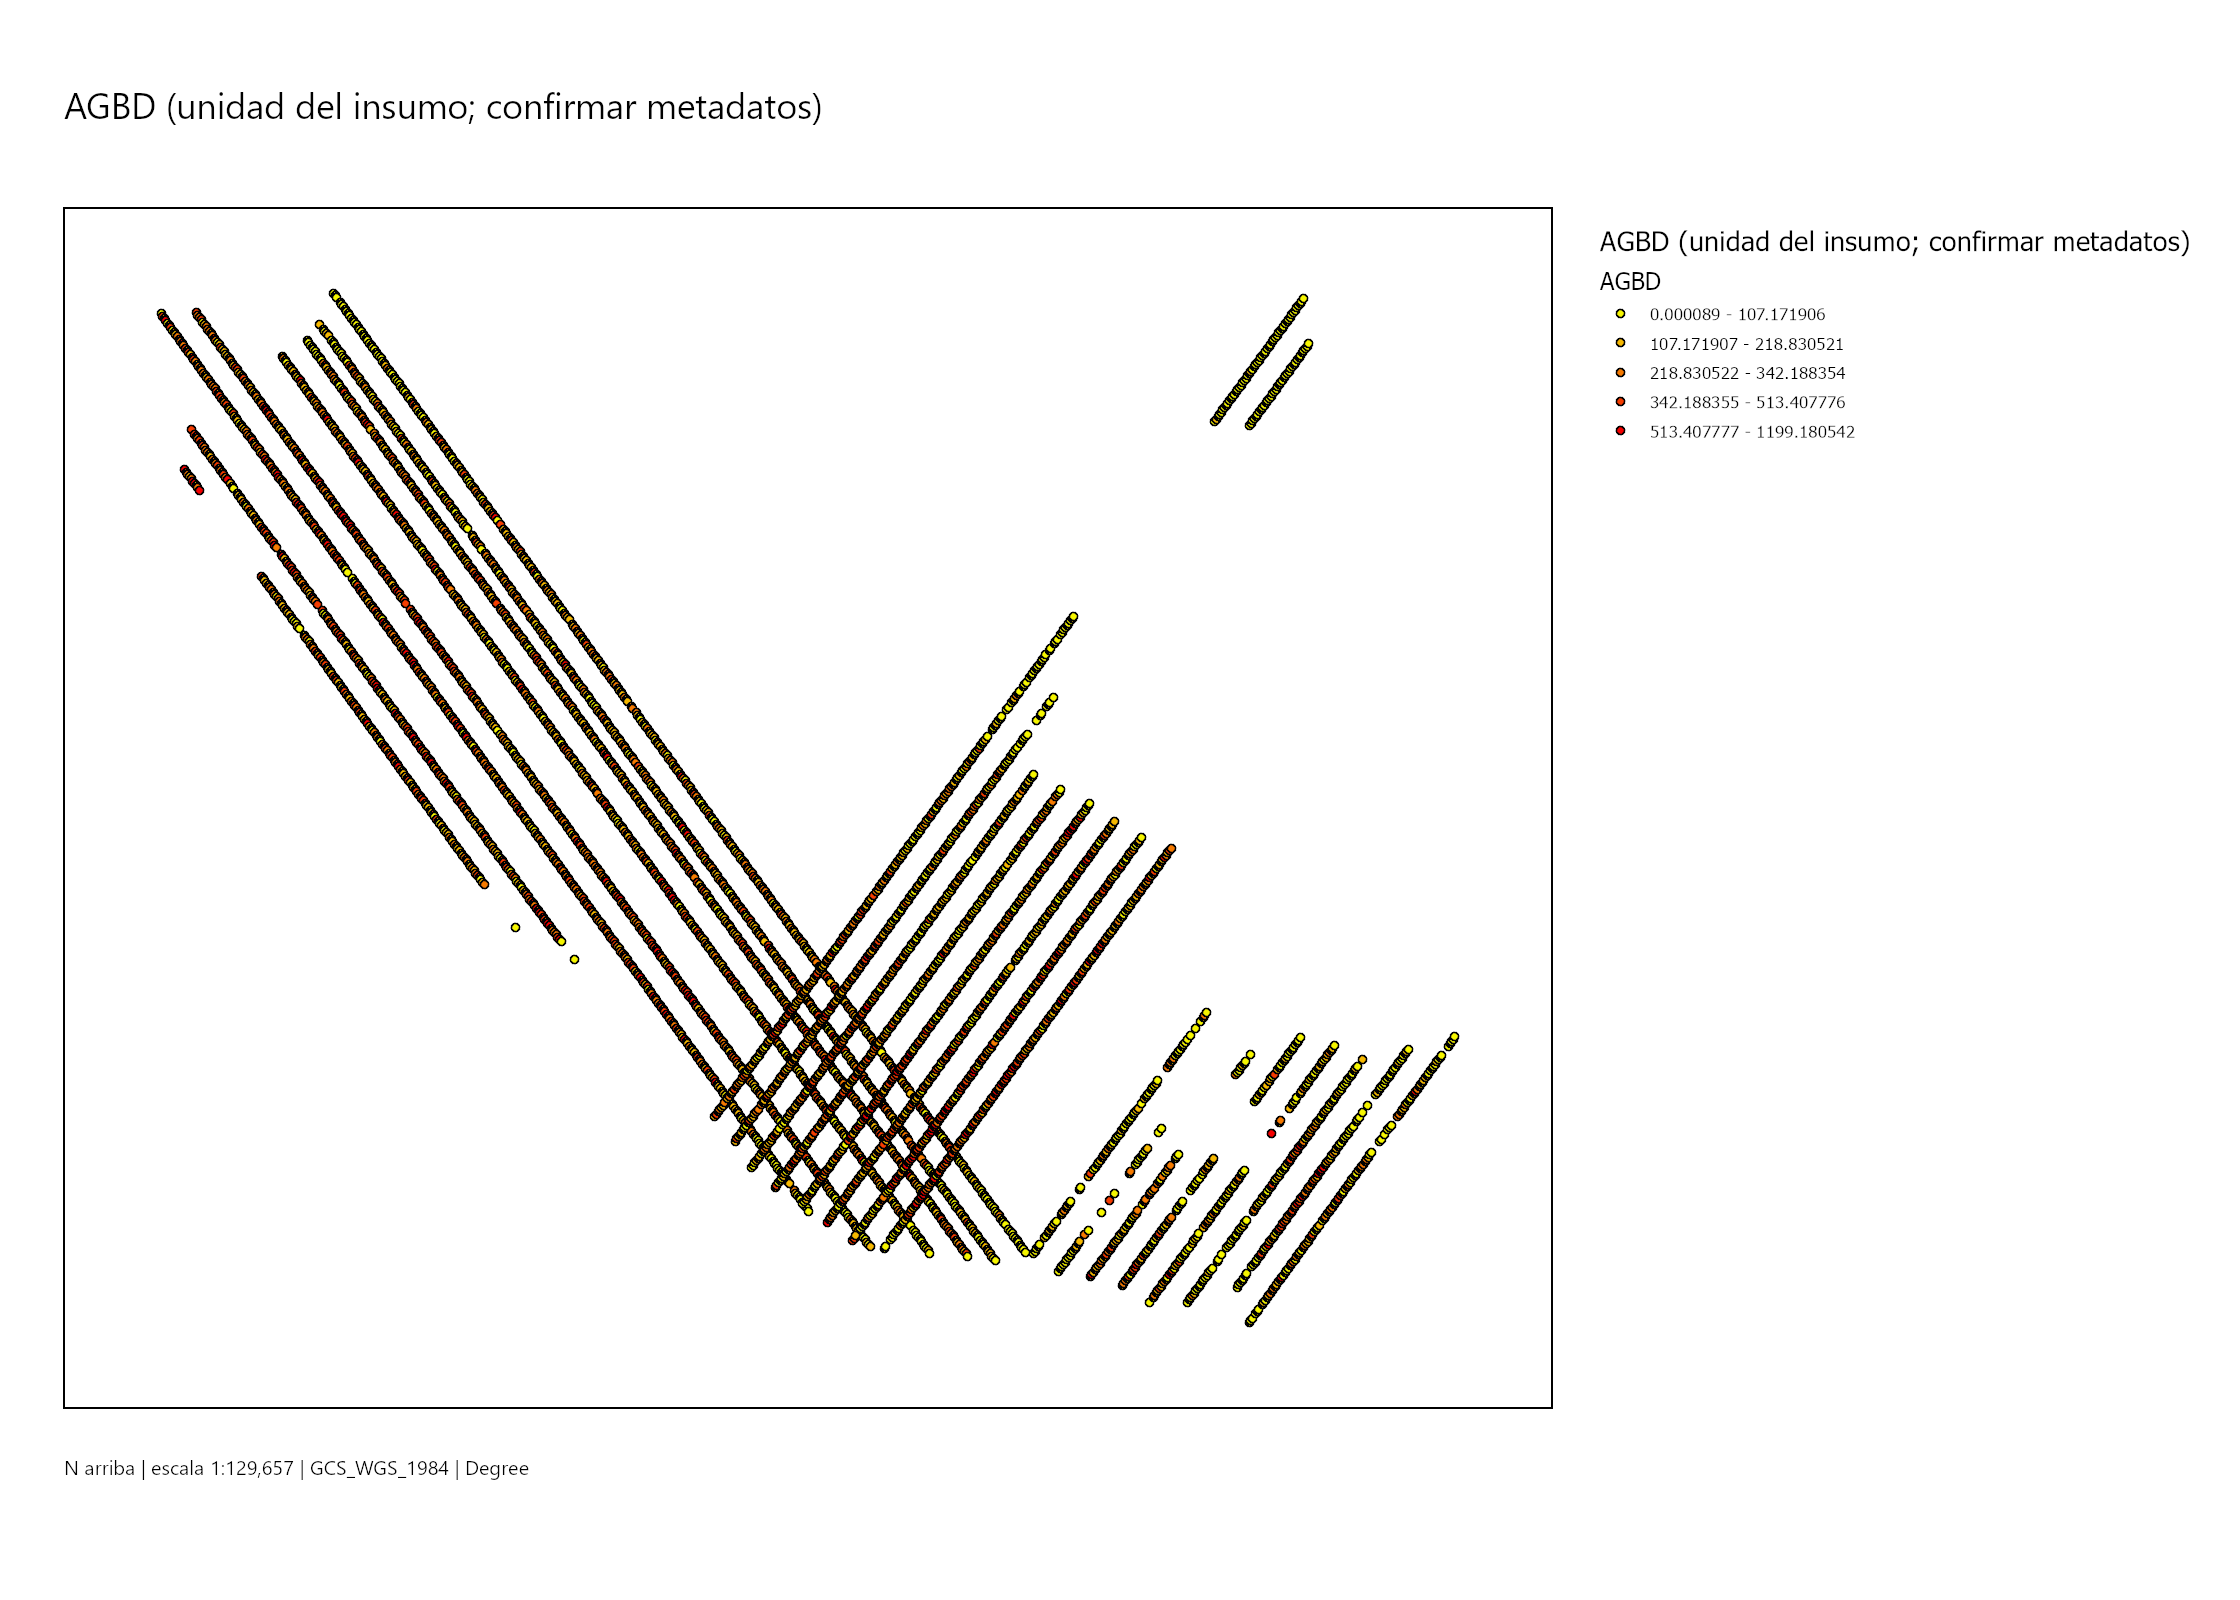

,AGBD
count,4946.000000
mean,222.645363
std,154.517476
min,0.000089
5%,10.438297
25%,108.774969
50%,201.334389
75%,309.022888
95%,515.355560
max,1199.180542


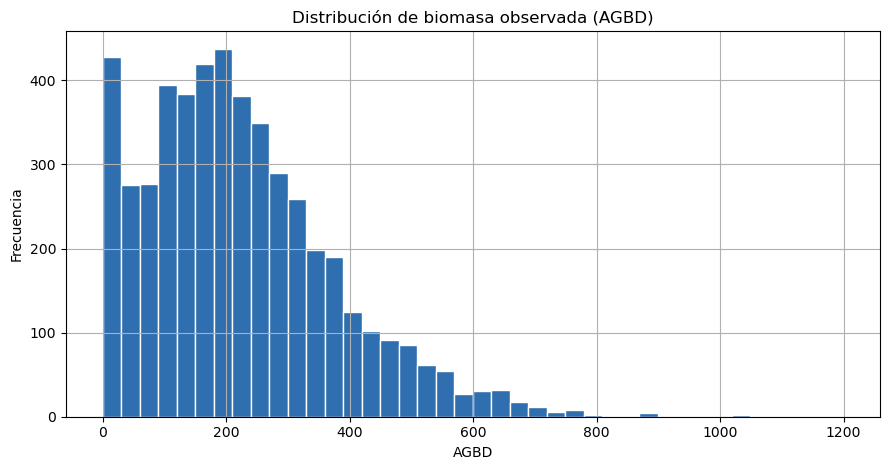

99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/clase_04_histograma_agbd.png


In [6]:
# Matplotlib es un complemento explícito, no sustituye mapas ni gráficos ArcGIS.
# Etapa de la práctica: entradas intactas; resultados en la carpeta de ejecución.
available = {f.name for f in arcpy.ListFields(str(POINTS_FC))}
requested = [arcpy.Describe(str(POINTS_FC)).OIDFieldName, 'lon', 'lat', 'Time', TARGET_FIELD, 'Trajectory']
if TARGET_FIELD not in available:
    raise ValueError('Falta la variable objetivo AGBD.')
print('Campos auxiliares ausentes:', sorted(set(requested)-available))
points_df = table_to_df(POINTS_FC, [f for f in requested if f in available])
display(pd.DataFrame([{'campo':f.name,'tipo':f.type,'alias':f.aliasName} for f in arcpy.ListFields(str(POINTS_FC))]))
print('Nulos:', points_df.isna().sum().to_dict())
print('Ceros AGBD:', int(points_df[TARGET_FIELD].eq(0).sum()))
for key in ['Time', 'Trajectory']:
    if key in points_df:
        print(key, 'distintos:', points_df[key].nunique(), 'repeticiones:', points_df[key].duplicated().sum())
print('CRS:', arcpy.Describe(str(POINTS_FC)).spatialReference.name)
eda_fc = WORK_GDB / 'agbd_eda'
arcpy.management.CopyFeatures(str(POINTS_FC), str(eda_fc))
native_chart(arcpy.charts.Histogram(x=TARGET_FIELD, dataSource=str(eda_fc), title='Distribución AGBD', xTitle='AGBD (Mg/ha)', yTitle='Frecuencia'), 'arcgis_histograma_agbd')
native_map(eda_fc, 'arcgis_agbd', TARGET_FIELD, 'Mg/ha')

summary = points_df[TARGET_FIELD].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame("AGBD")
display(summary)
summary.to_csv(OUT / "clase_04_agbd_resumen.csv", encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(9, 4.8))
points_df[TARGET_FIELD].dropna().hist(ax=ax, bins=40, color="#2f6fb0", edgecolor="white")
ax.set_title("Distribución de biomasa observada (AGBD)")
ax.set_xlabel("AGBD")
ax.set_ylabel("Frecuencia")
fig.tight_layout()
hist_path = OUT / "clase_04_histograma_agbd.png"
fig.savefig(hist_path, dpi=160)
plt.show()
print(rel(hist_path))


Compare media, mediana y percentiles con las colas de los histogramas; un extremo no autoriza eliminar una observación. Cero AGBD es un valor distinto de ausencia de dato. Time o Trajectory repetidos pueden reflejar el diseño de muestreo, no duplicados. El mapa revela dónde hay muestras, pero no certifica representatividad territorial ni identifica la unidad física de AGBD.

## 5. Proyectar puntos y extraer valores raster

La preparación convierte puntos y rasters en filas de entrenamiento: `Project` genera `agbd_observaciones_proyectadas` y `ExtractMultiValuesToPoints` agrega los 17 campos definidos, usando interpolación `BILINEAR`. La tabla de calidad resume nulos, mínimo, mediana y máximo por objetivo/predictor; `complete_mask` exige los 18 valores presentes. No imputa datos.

La referencia se obtiene del CRS real de `NDVI_Mask`, sin imponer un EPSG. Proyecciones distintas no implican incompatibilidad: **Extract Multi Values to Points** conserva la resolución y referencia espacial originales de cada raster y proyecta las ubicaciones de entrada a esa referencia para extraer valores. `BILINEAR` interpola los valores en esas ubicaciones; no crea rasters remuestreados. La herramienta modifica los puntos de entrada, por lo que recibe exclusivamente `projected_points`, la nueva copia proyectada en `WORK_GDB`, nunca las observaciones originales. Fuente: Esri, ArcGIS Pro 3.6, [Extract Multi Values to Points — Usage y Parameters](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-analyst/extract-multi-values-to-points.htm), pasaje verificado el 2026-09-21.

La comprobación permite CRS conocidos con distintas proyecciones si comparten un código GCS positivo y el mismo datum identificado. Imprime estos datos para puntos y rasters. Un CRS desconocido, código GCS no identificable o GCS/datum diferente detiene el proceso: requiere una decisión explícita sobre referencia y transformación, sin adivinarla ni elegir automáticamente una transformación. Esta comprobación no demuestra coincidencia de cobertura, resolución o fechas; los nulos extraídos se revisan después.


In [7]:
# Etapa de la práctica: entradas intactas; resultados en la carpeta de ejecución.
reference_raster = SOURCE_GDB / "NDVI_Mask"
reference_sr = arcpy.Describe(str(reference_raster)).spatialReference

# Comparar el GCS/datum real, no las cadenas de proyección ni un EPSG supuesto.
def gcs_identity(sr, label):
    if sr.type not in ('Projected', 'Geographic') or not sr.name or sr.name == 'Unknown':
        raise ValueError(f'{label}: CRS desconocido; decidir explícitamente CRS y transformación antes de continuar.')
    gcs = sr.GCS if sr.type == 'Projected' else sr
    code = gcs.factoryCode
    datum = gcs.datumName
    if not code or code <= 0 or not datum or datum.lower() == 'unknown':
        raise ValueError(f'{label}: GCS/datum no identificable; se requiere decisión explícita de transformación.')
    print(label, '| CRS:', sr.name, '| GCS:', code, '| datum:', datum)
    return code, datum

reference_identity = gcs_identity(reference_sr, 'NDVI_Mask (referencia)')
for raster, field, description in RASTER_SPECS:
    sr = arcpy.Describe(str(SOURCE_GDB / raster)).spatialReference
    if gcs_identity(sr, raster) != reference_identity:
        raise ValueError(f'{raster}: GCS/datum distinto; decidir explícitamente la transformación antes de extraer.')
source_sr = arcpy.Describe(str(POINTS_FC)).spatialReference
if gcs_identity(source_sr, POINTS_FC.name) != reference_identity:
    raise ValueError('Puntos: GCS/datum distinto; decidir explícitamente la transformación antes de proyectar.')
print('CRS observado:', reference_sr.name, reference_sr.linearUnitName)
projected_points = WORK_GDB / "agbd_observaciones_proyectadas"

arcpy.management.Project(str(POINTS_FC), str(projected_points), reference_sr)

extract_pairs = [[str(SOURCE_GDB / raster), field] for raster, field, _ in RASTER_SPECS]
arcpy.sa.ExtractMultiValuesToPoints(str(projected_points), extract_pairs, "BILINEAR")

model_fields = [field for _, field, _ in RASTER_SPECS]
all_fields = ["OBJECTID", TARGET_FIELD] + model_fields
extracted_df = table_to_df(projected_points, all_fields)

quality = []
for field in [TARGET_FIELD] + model_fields:
    s = extracted_df[field]
    quality.append({
        "campo": field,
        "nulos": int(s.isna().sum()),
        "mínimo": float(s.min(skipna=True)),
        "mediana": float(s.median(skipna=True)),
        "máximo": float(s.max(skipna=True)),
    })
quality_df = pd.DataFrame(quality)
display(quality_df)
quality_df.to_csv(OUT / "clase_04_calidad_variables.csv", index=False, encoding="utf-8-sig")

complete_mask = extracted_df[[TARGET_FIELD] + model_fields].notna().all(axis=1)
print(f"Puntos originales: {len(extracted_df):,}")
print(f"Puntos completos para modelar: {complete_mask.sum():,}")
print(f"Puntos excluidos por nulos en objetivo o rasters: {(~complete_mask).sum():,}")


NDVI_Mask (referencia) | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
LC09_20230222_B1_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
LC09_20230222_B2_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
LC09_20230222_B3_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
LC09_20230222_B4_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
LC09_20230222_B5_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
LC09_20230222_B6_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
LC09_20230222_B7_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
NDVI_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
EVI_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
SAVI_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
MNDWI_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984


MSI_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
RVI_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984


DVI_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
DEM_30_Mask | CRS: GCS_WGS_1984 | GCS: 4326 | datum: D_WGS_1984


Slope_DEM_30 | CRS: GCS_WGS_1984 | GCS: 4326 | datum: D_WGS_1984
Aspect_DEM_30 | CRS: GCS_WGS_1984 | GCS: 4326 | datum: D_WGS_1984


AGBD_Observaciones_2023_Coiba | CRS: GCS_WGS_1984 | GCS: 4326 | datum: D_WGS_1984
CRS observado: WGS_1984_UTM_Zone_17N Meter


,campo,nulos,mínimo,mediana,máximo
0,AGBD,0,0.000089,201.334389,1199.180542
1,B1,44,7117.746094,7826.581299,9447.990234
2,B2,44,7386.091797,7850.402588,9758.607422
3,B3,44,7985.909180,8680.431641,11523.437500
4,B4,44,7550.562012,7995.219727,11845.003906
5,B5,44,10498.062500,19899.978516,25703.361328
6,B6,44,9011.052734,11935.670410,16751.845703
7,B7,44,7999.437988,9032.424316,12488.112305
8,NDVI,44,0.121096,0.425935,0.516849
9,EVI,44,-332.947083,3.287647,20.570656


Puntos originales: 4,946
Puntos completos para modelar: 4,840
Puntos excluidos por nulos en objetivo o rasters: 106


### ¿Cuántos árboles entran al modelo? Primero, distinguir qué contamos

La pregunta es: **¿podemos estimar AGBD de un lugar a partir de sus bandas, índices y relieve?** Imagine una tabla: cada fila es una observación puntual; sus columnas describen ese lugar; AGBD es la respuesta que queremos aprender. No contamos troncos. Los **4.946 registros puntuales** no demuestran 4.946 árboles físicos, parcelas ni huellas GEDI: la procedencia y unidad física de muestreo no están acreditadas. AGBD se interpreta en **Mg/ha por confirmación previa del usuario**, no por el nombre del campo ni por metadatos; véase la [procedencia local de Coiba](../datos/clase_04/README.md).

Cada fila reúne **17 predictores**: siete bandas Landsat 9 (`B1`–`B7`), siete índices (`NDVI`, `EVI`, `SAVI`, `MNDWI`, `MSI`, `RVI`, `DVI`) y tres variables topográficas (`DEM`, `Slope`, `Aspect`). AGBD es una columna adicional, no el predictor 18. Así, una fila completa necesita **18 valores presentes: 17 entradas + 1 respuesta**. Coordenadas e identificadores sitúan o identifican registros, pero no figuran en la lista de predictores de esta llamada. Los índices comparten bandas: 17 columnas no son 17 fuentes independientes.

Lea cada fila de calidad antes de entrenar: nulos pueden reflejar NoData o falta de cobertura, no biomasa cero. Los conteos deben cumplir total = completos + excluidos; la salida actual registra 4.946 observaciones, 4.840 completas y 106 fuera del modelo, conservadas en la copia proyectada. Compartir GCS/datum permite esta ruta de extracción, pero no demuestra alineación temporal ni equivalencia entre píxel y huella de campo.

## 6. Guardar la selección de entrenamiento

Sobre `projected_points`, Make Feature Layer crea una referencia temporal y Select Layer By Attribute aplica `NEW_SELECTION` con `IS NOT NULL` para AGBD y los 17 campos unidos por AND. Copy Features persiste solo ese subconjunto; Get Count contrasta SQL con `complete_mask`. `seleccion_modelo.csv` conserva la marca de selección para todas las filas extraídas.

La selección de casos completos se copia a `WORK_GDB/complete_case_training`: una entidad persistente permite que los gráficos nativos reciban una ruta real, no el nombre transitorio de una capa. No es limpieza automática. Todas las observaciones permanecen en la copia proyectada; `seleccion_modelo.csv` identifica las excluidas. No se imputan nulos, deduplican claves o reparan geometrías. La ausencia de cobertura raster puede sesgar territorialmente la selección. La salida confirma 4.840 seleccionados; los otros 106 registros permanecen disponibles para estudiar el sesgo de cobertura.


In [8]:
# Selección explícita de casos completos; ninguna observación se elimina de la copia.
where = ' AND '.join(arcpy.AddFieldDelimiters(str(projected_points), f) + ' IS NOT NULL' for f in [TARGET_FIELD] + model_fields)
selected_layer = 'coiba_complete_case_training'
arcpy.management.MakeFeatureLayer(str(projected_points), selected_layer)
arcpy.management.SelectLayerByAttribute(selected_layer, 'NEW_SELECTION', where)
# Copia persistente de la selección para gráficos nativos; no es limpieza automática.
# projected_points conserva todos los puntos extraídos, incluidos los excluidos del modelo.
training_fc = str(WORK_GDB / 'complete_case_training')
arcpy.management.CopyFeatures(selected_layer, training_fc)
training_count = int(arcpy.management.GetCount(training_fc)[0])
print('Conservados:', len(extracted_df), 'seleccionados:', training_count, 'excluidos:', len(extracted_df)-training_count)
if training_count == 0 or training_count != int(complete_mask.sum()):
    raise ValueError('Selección vacía o discrepancia entre SQL y revisión tabular.')
extracted_df.assign(SELECCION_MODELO=complete_mask).to_csv(OUT / 'seleccion_modelo.csv', index=False)


Conservados: 4946 seleccionados: 4840 excluidos: 106


### Tres conteos, no tres tamaños del bosque

Piense en revisar formularios antes de estudiar sus respuestas: conservar todos no significa poder usar todos para aprender. La salida anterior permite comprobar:

| Conteo observado | Qué cuenta | Qué no significa |
|---|---|---|
| **4.946 conservados** | Todas las filas de la copia proyectada | Árboles físicos o filas usadas todas para ajustar |
| **4.840 seleccionados** | Casos con AGBD y los 17 predictores presentes | Tamaño exacto de entrenamiento tras reservar validación |
| **106 excluidos** | Filas incompletas que no pasan a `complete_case_training` | Filas borradas o el 10% retenido para validación |

La cuenta es **4.946 = 4.840 + 106**. La tabla de calidad muestra cero nulos en AGBD y faltantes en predictores extraídos; NoData no se convierte en biomasa cero. Tampoco se suman los nulos de todas las columnas para contar personas o lugares: una misma fila puede carecer de varios predictores. Los 106 registros permanecen en la copia proyectada y su marca se conserva en `seleccion_modelo.csv`. No se imputan ni se borran.

La reserva de validación ocurre **después**, sobre los casos completos: separa ejemplos utilizables para comprobar el modelo, no rescata los incompletos. Una selección vacía o discordante detiene el flujo. La coincidencia de conteos valida la selección, no elimina su posible sesgo geográfico: las áreas sin cobertura pueden quedar menos representadas.

## 7. Revisar relaciones simples antes del modelo

Desde `training_fc`, cuatro dispersiones comparan AGBD con NDVI, EVI, DEM y Slope. Los puntos pequeños con transparencia 0,25 permiten reconocer concentraciones sin agregar ni ajustar una curva. La salida nativa usa NDVI como X y AGBD como Y; ambas presentaciones describen únicamente casos completos.

Se conservan las cuatro dispersiones originales de Matplotlib (NDVI, EVI, DEM, Slope). El gráfico nativo ArcGIS de NDVI frente a AGBD complementa la comparación: cada punto es un caso completo seleccionado; curvatura o dispersión no prueban causalidad, y la selección puede excluir zonas sin cobertura.


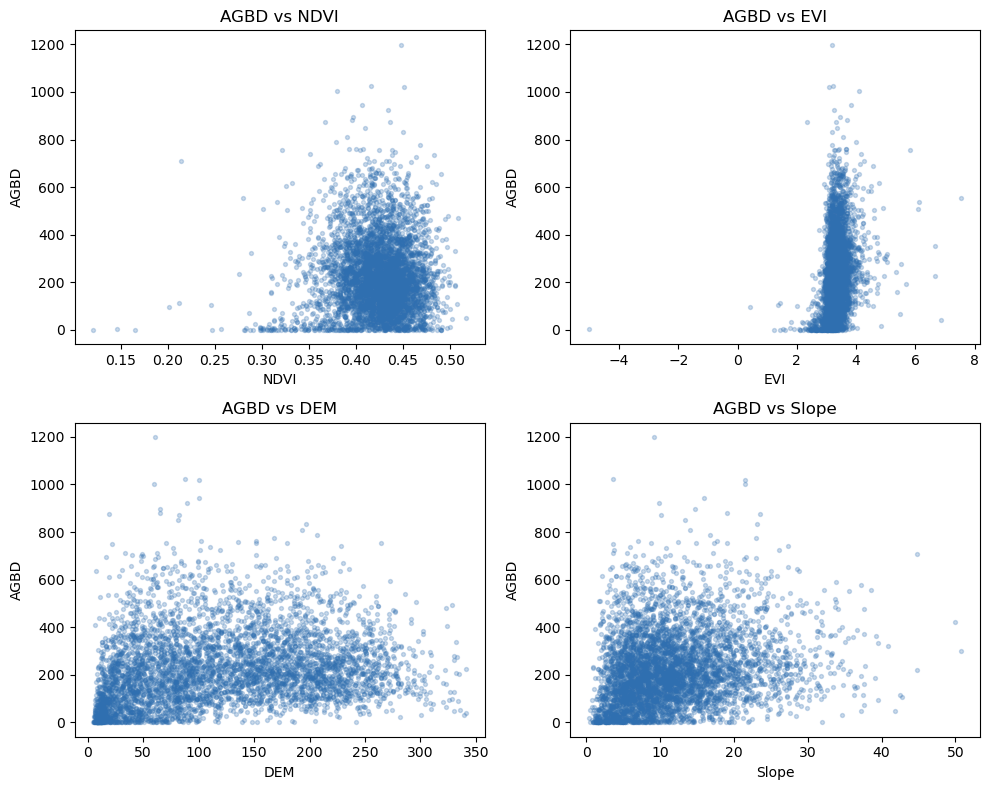

99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/clase_04_dispersion_agbd_variables.png


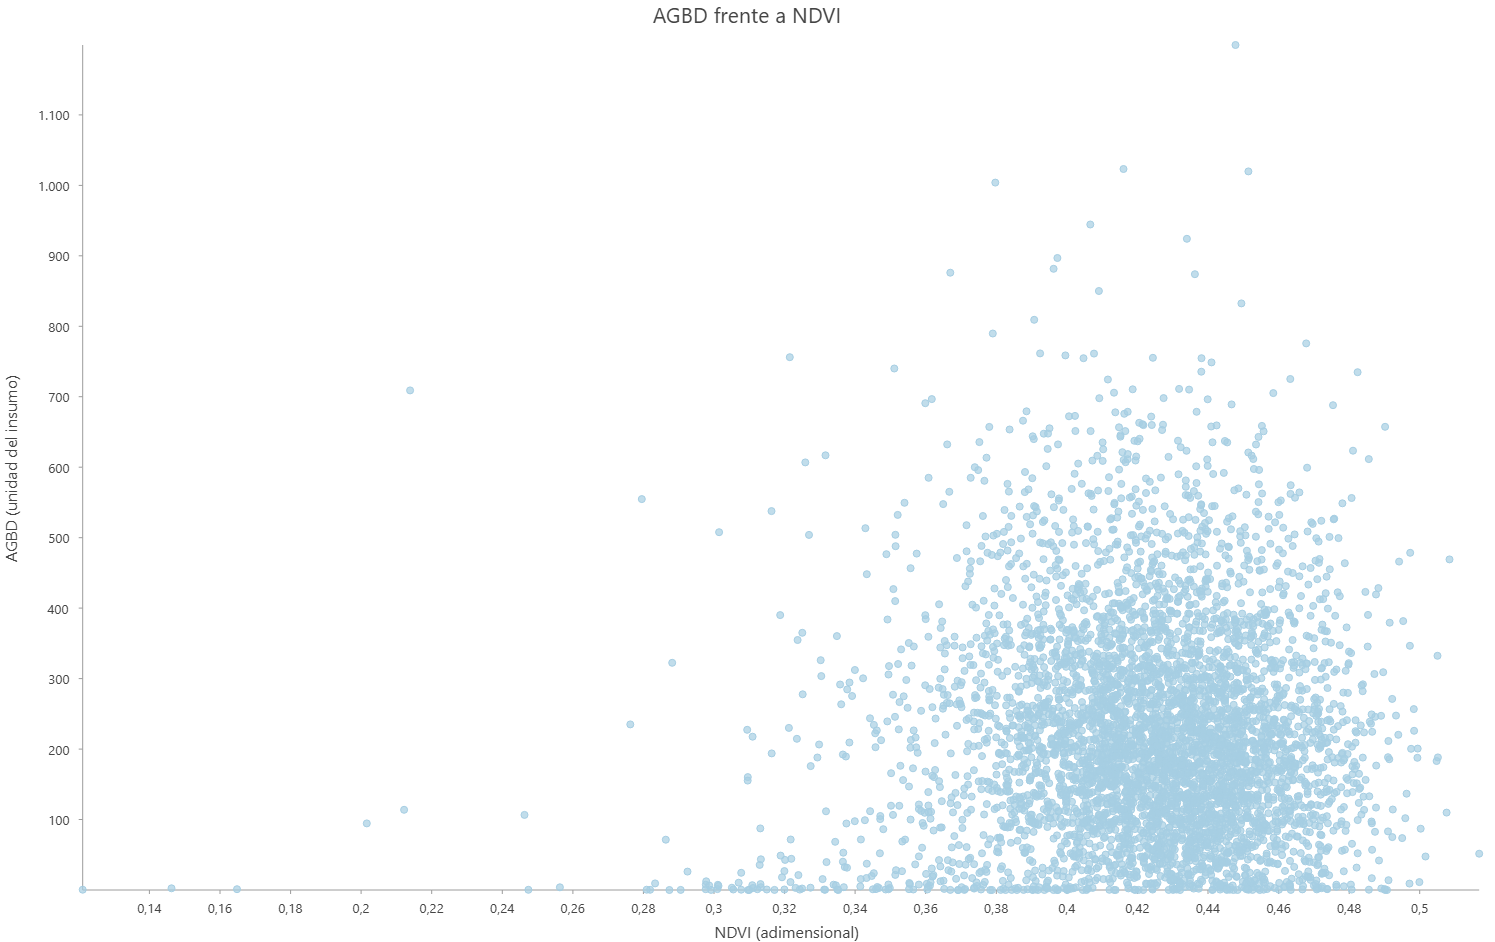

In [9]:
# Matplotlib es un complemento explícito, no sustituye mapas ni gráficos ArcGIS.
# Etapa de la práctica: entradas intactas; resultados en la carpeta de ejecución.
plot_df = table_to_df(training_fc, [TARGET_FIELD, "NDVI", "EVI", "DEM", "Slope"])

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, field in zip(axes.ravel(), ["NDVI", "EVI", "DEM", "Slope"]):
    ax.scatter(plot_df[field], plot_df[TARGET_FIELD], s=8, alpha=0.25, color="#2f6fb0")
    ax.set_xlabel(field)
    ax.set_ylabel("AGBD")
    ax.set_title(f"AGBD vs {field}")
fig.tight_layout()
scatter_path = OUT / "clase_04_dispersion_agbd_variables.png"
fig.savefig(scatter_path, dpi=160)
plt.show()
print(rel(scatter_path))

native_chart(arcpy.charts.Scatter(x='NDVI', y=TARGET_FIELD, dataSource=training_fc, title='AGBD frente a NDVI', xTitle='NDVI (adimensional)', yTitle='AGBD (Mg/ha)'), 'arcgis_agbd_ndvi')


Busque curvaturas, franjas, saturación y observaciones aisladas en las dispersiones, respetando las unidades diferentes de cada eje. Una nube poco lineal no demuestra inutilidad de un predictor para un bosque. Estos gráficos no evalúan datos retenidos ni prueban generalización a otros lugares o fechas: muestran relaciones marginales de la muestra seleccionada.

## 8. Entrenar Forest-based Regression

`TRAIN` aprende AGBD continua de `complete_case_training` con los 17 campos extraídos marcados no categóricos. Produce `rf_agbd_trained_features`, `rf_agbd_importance`, `rf_agbd_coiba.ssm` y un reporte HTML en destinos nuevos. No crea una superficie raster ni demuestra por sí solo transferencia territorial.

### Un bosque digital: varias reglas para una misma pregunta

Imagine **30 estimadores basados en reglas** que examinan filas y columnas de la tabla. Cada árbol aprende preguntas sucesivas sobre predictores, como «¿NDVI supera cierto umbral?», y llega a una hoja con una predicción numérica. El umbral de este ejemplo es conceptual: no estamos mostrando una regla extraída del modelo. Para una ubicación descrita por sus 17 valores, el bosque de regresión **promedia las predicciones**, no cuenta árboles de Coiba ni vota una clase.

La idea se resume en $\hat{y}(x)=\frac{1}{30}\sum_{t=1}^{30}\hat{y}_t(x)$: $x$ contiene los predictores del lugar y $\hat{y}_t$ es la estimación del árbol digital $t$. **Ejemplo hipotético con solo tres estimadores**, no una salida real: si predijeran 180, 210 y 240 Mg/ha, el promedio sería $(180+210+240)/3=210$ Mg/ha. El modelo de esta práctica usa 30, no tres. Promediar puede reducir la dependencia de una sola regla, pero no corrige por sí mismo sesgos de cobertura o falta de independencia espacial. Véanse Breiman (2001), citado al inicio, y Esri, [funcionamiento del bosque, Pro 3.6](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/how-forest-works.htm).

### Leer cada control sin confundir filas, columnas y árboles

| Parámetro real | Explicación para esta práctica | Efecto y límite |
|---|---|---|
| `number_of_trees=30` | 30 árboles de decisión digitales combinan sus estimaciones | No son observaciones ni un censo forestal; más árboles no garantizan generalización |
| `minimum_leaf_size=5` | El tamaño mínimo de hoja se expresa en observaciones de entrenamiento | No significa cinco árboles físicos; limita cuánto puede especializarse una regla terminal |
| `maximum_depth=20` | Tope de profundidad: limita la cadena de divisiones desde la raíz hacia una hoja | No ordena que todos los árboles alcancen 20; permite reglas más detalladas sin garantizar mejor validación |
| `random_variables=5` | En cada división se consideran cinco variables candidatas de las 17 disponibles | No selecciona cinco columnas fijas para todo el bosque: otras divisiones pueden considerar otras candidatas |
| `sample_size=100` | 100% de los datos de entrenamiento disponibles por árbol, como lo rotula el reporte | Se refiere al conjunto de entrenamiento, no a incorporar el holdout; por sí solo no describe qué filas únicas usa cada árbol ni demuestra ausencia de muestreo |
| `percentage_for_training=10` | Aunque el nombre pueda confundir, ArcGIS reporta **10% excluido para validación** | No significa entrenar con solo 10%; es un parámetro, no un conteo observado por corrida |
| `number_validation_runs=2` | Dos ejecuciones de validación para examinar variación entre particiones | No son dos árboles, dos observaciones ni una validación espacial por bloques |

Los **17** describen las columnas disponibles; los **5** restringen la competencia de variables en una división; los **30** cuentan los estimadores. Son tres decisiones distintas. Los porcentajes también tienen bases distintas: reservar validación y disponer de entrenamiento por árbol no se contradicen. Referencia: Esri, [Forest, Pro 3.6 — Parameters](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/forestbasedclassificationregression.htm).

Parámetros base (resumen de la llamada siguiente):

- `model_type="FOREST-BASED"`
- variable objetivo numérica: `AGBD`
- 30 árboles para un ejercicio exploratorio; sin semilla fijada no se esperan resultados idénticos;
- 10% de datos excluidos para validación;
- variables candidatas en las divisiones del árbol: 5;
- profundidad máxima: 20;
- tamaño mínimo de hoja: 5.

> En un proyecto final conviene probar más árboles, varias semillas, validación espacial y sensibilidad de hiperparámetros.

Se mantienen `sample_size=100` y dos ejecuciones de validación; no se fija una semilla nueva. Los resultados pueden variar entre corridas. Véase Esri, Pro 3.6, [parámetros Forest](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/forestbasedclassificationregression.htm) y [funcionamiento y diagnósticos](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/how-forest-works.htm).


In [10]:
# Etapa de la práctica: entradas intactas; resultados en la carpeta de ejecución.
trained_features = WORK_GDB / "rf_agbd_trained_features"
importance_table = WORK_GDB / "rf_agbd_importance"
trained_model = OUT / "rf_agbd_coiba.ssm"

explanatory_variables = [[field, "false"] for field in model_fields]

result = arcpy.stats.Forest(
    prediction_type="TRAIN",
    in_features=str(training_fc),
    variable_predict=TARGET_FIELD,
    treat_variable_as_categorical="NUMERIC",
    explanatory_variables=explanatory_variables,
    output_trained_features=str(trained_features),
    output_importance_table=str(importance_table),
    number_of_trees=30,
    minimum_leaf_size=5,
    maximum_depth=20,
    sample_size=100,
    random_variables=5,
    percentage_for_training=10,  # ArcGIS lo reporta como % excluido para validación.
    number_validation_runs=2,
    output_trained_model=str(trained_model),
    model_type="FOREST-BASED",
)

messages = arcpy.GetMessages()
forest_html = forest_messages_to_html(messages)
html_path = OUT / "clase_04_rf_diagnostico_arcgis.html"
html_path.write_text(forest_html, encoding="utf-8")

# Salida completa de la herramienta como HTML dentro del notebook.
display(HTML(forest_html))

print("Capa entrenada:", rel(trained_features))
print("Importancia:", rel(importance_table))
print("Modelo SSM:", rel(trained_model))
print("Reporte HTML ArcGIS:", rel(html_path))


Capa entrenada: 99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/clase_04_coiba_rf.gdb/rf_agbd_trained_features
Importancia: 99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/clase_04_coiba_rf.gdb/rf_agbd_importance
Modelo SSM: 99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/rf_agbd_coiba.ssm
Reporte HTML ArcGIS: 99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/clase_04_rf_diagnostico_arcgis.html


### ¿El modelo aprendió una relación o recuerda sus ejemplos?

Piense en estudiar con ejercicios y después resolver otros que no vio al aprender. **Entrenamiento** mide el ajuste a los ejemplos usados para aprender; **validación retenida (holdout)** evalúa ejemplos apartados del entrenamiento; **fuera de bolsa (OOB)** evalúa observaciones con los árboles para cuyo ajuste no se usaron. OOB no es otro nombre del holdout ni garantiza independencia geográfica. Compare sus diagnósticos separados, no solo el mejor R². Fuente: Esri, [Pro 3.6 — funcionamiento y diagnósticos](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/how-forest-works.htm).

**Qué confirma el HTML guardado:** 30 árboles, hoja 5, cinco variables candidatas, 100% disponible por árbol y 10% excluido para validación. El rango de profundidad **20–20** y la media **20** son resultados de esta ejecución histórica; el parámetro máximo 20, por sí solo, no los garantizaba. La tabla OOB compara el error con 15 y 30 árboles; esos dos puntos del diagnóstico no son las dos ejecuciones de validación.

**Qué no confirma:** el reporte no imprime los conteos exactos de entrenamiento y holdout por corrida. Por eso no convertimos el porcentaje en cantidades observadas: solo sabemos que la entrada seleccionada tiene 4.840 casos completos y que se solicitó retener 10%. Tampoco la tabla posterior de predicciones y residuales reconstruye qué registros integraron el holdout; un residual $e_i=y_i-\hat{y}_i$ describe una diferencia, no la pertenencia a una partición. Sus métricas no deben reemplazar las de Validation Data.

No hay una semilla fijada en la configuración del notebook. El HTML registra **551717** y señala **548499** como la semilla que aproximadamente alcanzó el R² mediano de validación; son referencias históricas distintas, no una promesa de reproducción exacta. Reservar 10% y repetir dos veces no garantiza estabilidad ni independencia espacial: lugares vecinos pueden compartir condiciones ambientales.

Las rutas impresas aquí identifican salidas `TRAIN`, no `PREDICT_RASTER`. La salida histórica de configuración (`6efdddca`) menciona `datos/clase_06`, mientras el código actual dirige la entrada a `datos/clase_04`: se conserva esa evidencia, no se presenta como una nueva ejecución. Esta ampliación docente no reejecuta el notebook. Un aviso de rangos pide revisar representatividad; la lectura siguiente interpreta el reporte guardado.


## 8.1 Interpretación del reporte de ArcGIS

| Conjunto TRAIN | R² | MAE | RMSE |
|---|---:|---:|---:|
| Entrenamiento | 0,890 | 46,075 | 62,680 |
| Validación retenida | 0,196 | 109,068 | 140,597 |

Fuente: [reporte TRAIN](../salidas_clase_04/publicados/clase_04_rf_diagnostico_arcgis.html), Training/Validation Data. R² es adimensional; MAE y RMSE conservan la unidad AGBD del insumo: Mg/ha. El bosque reproduce mucho mejor los datos usados para aprender que los retenidos: el error aumenta y R² cae. La validación es débil para un producto final; no basta con mostrar el ajuste alto.

El error fuera de bolsa no usa la misma partición retenida: el reporte indica 2,076% de variación explicada con 30 árboles. Es otra señal de capacidad predictiva limitada, no validación territorial. Las marcas `*` señalan rangos de entrenamiento/validación incompletos; una partición aleatoria 90/10 puede representar mal gradientes ambientales. Validación espacial por bloques y contraste de rangos serían pruebas posteriores. [Esri Pro 3.6, diagnósticos](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/how-forest-works.htm).


## 9. Leer importancia de variables

Se lee `rf_agbd_importance`, se transpone su primera fila y se normaliza cada valor por la suma para obtener porcentajes. Antes de interpretar, contraste la tabla cruda y sus campos reales: `numeric_cols` excluye `BEST_ITE`, pero su nombre no implica una comprobación de tipo. Este código presupone que las columnas restantes son importancias numéricas de predictores y que su suma no es cero; no confunda metadatos o columnas nuevas con variables explicativas.

Las barras nativas muestran porcentajes normalizados de la tabla del bosque. Compare longitud y orden, no interprete ese porcentaje como efecto causal ni como porcentaje de biomasa explicado. Se conserva también la figura original de Matplotlib.


,B1,B2,B3,B4,B5,B6,B7,NDVI,EVI,SAVI,MNDWI,MSI,RVI,DVI,DEM,SLOPE,ASPECT,BEST_ITE
0,5.308660e+06,5.797967e+06,5.644434e+06,7.745385e+06,2.951882e+06,6.721784e+06,7.237046e+06,2.888337e+06,6.172058e+06,2.834129e+06,6.333850e+06,4.299648e+06,3.019686e+06,2.789285e+06,1.157443e+07,6.013685e+06,5.799541e+06,Iterations
1,6.308453e+06,5.293704e+06,5.399855e+06,8.586904e+06,2.858736e+06,5.380277e+06,7.354005e+06,2.686588e+06,6.019259e+06,2.736754e+06,6.116516e+06,4.350635e+06,2.854866e+06,3.002508e+06,1.402133e+07,6.558654e+06,6.043891e+06,Best Iteration


,variable,importancia,porcentaje
14,DEM,1.157443e+07,12.428012
3,B4,7.745385e+06,8.316583
6,B7,7.237046e+06,7.770756
5,B6,6.721784e+06,7.217496
10,MNDWI,6.333850e+06,6.800953
8,EVI,6.172058e+06,6.627229
15,SLOPE,6.013685e+06,6.457176
16,ASPECT,5.799541e+06,6.227240
1,B2,5.797967e+06,6.225549
2,B3,5.644434e+06,6.060694


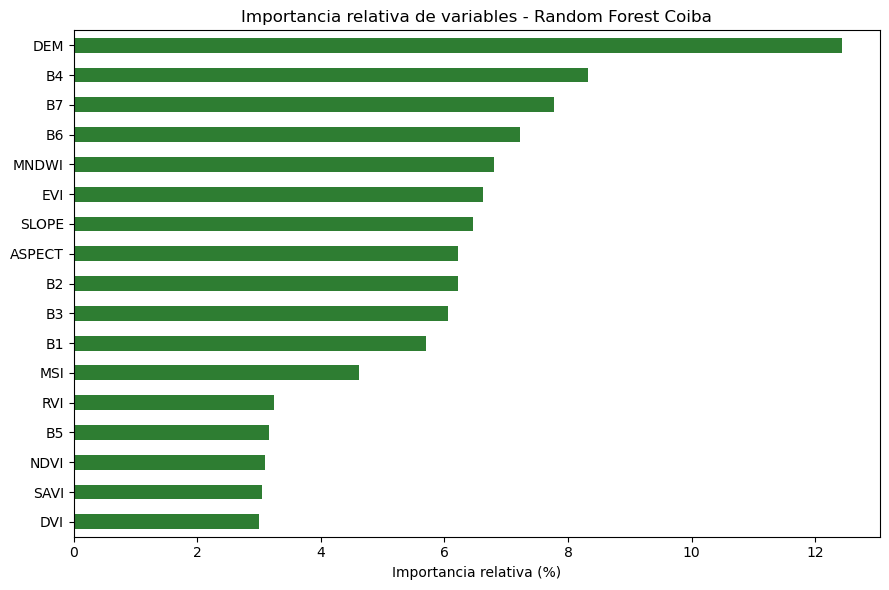

99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/clase_04_importancia_variables.png


### Interpretación de importancia

La tabla de importancia indica qué variables redujeron más el error del modelo forest-based en esta corrida. No debe leerse como causalidad.

Variables con mayor peso relativo:
- **DEM**: 12.4%
- **B4**: 8.3%
- **B7**: 7.8%
- **B6**: 7.2%
- **MNDWI**: 6.8%

NDVI quedó con 3.1% de importancia relativa en esta corrida.

Si NDVI queda bajo frente a bandas o variables topográficas, la lectura metodológica es revisar colinealidad, saturación del índice en vegetación densa y coherencia temporal con los puntos de biomasa, no eliminarlo automáticamente.

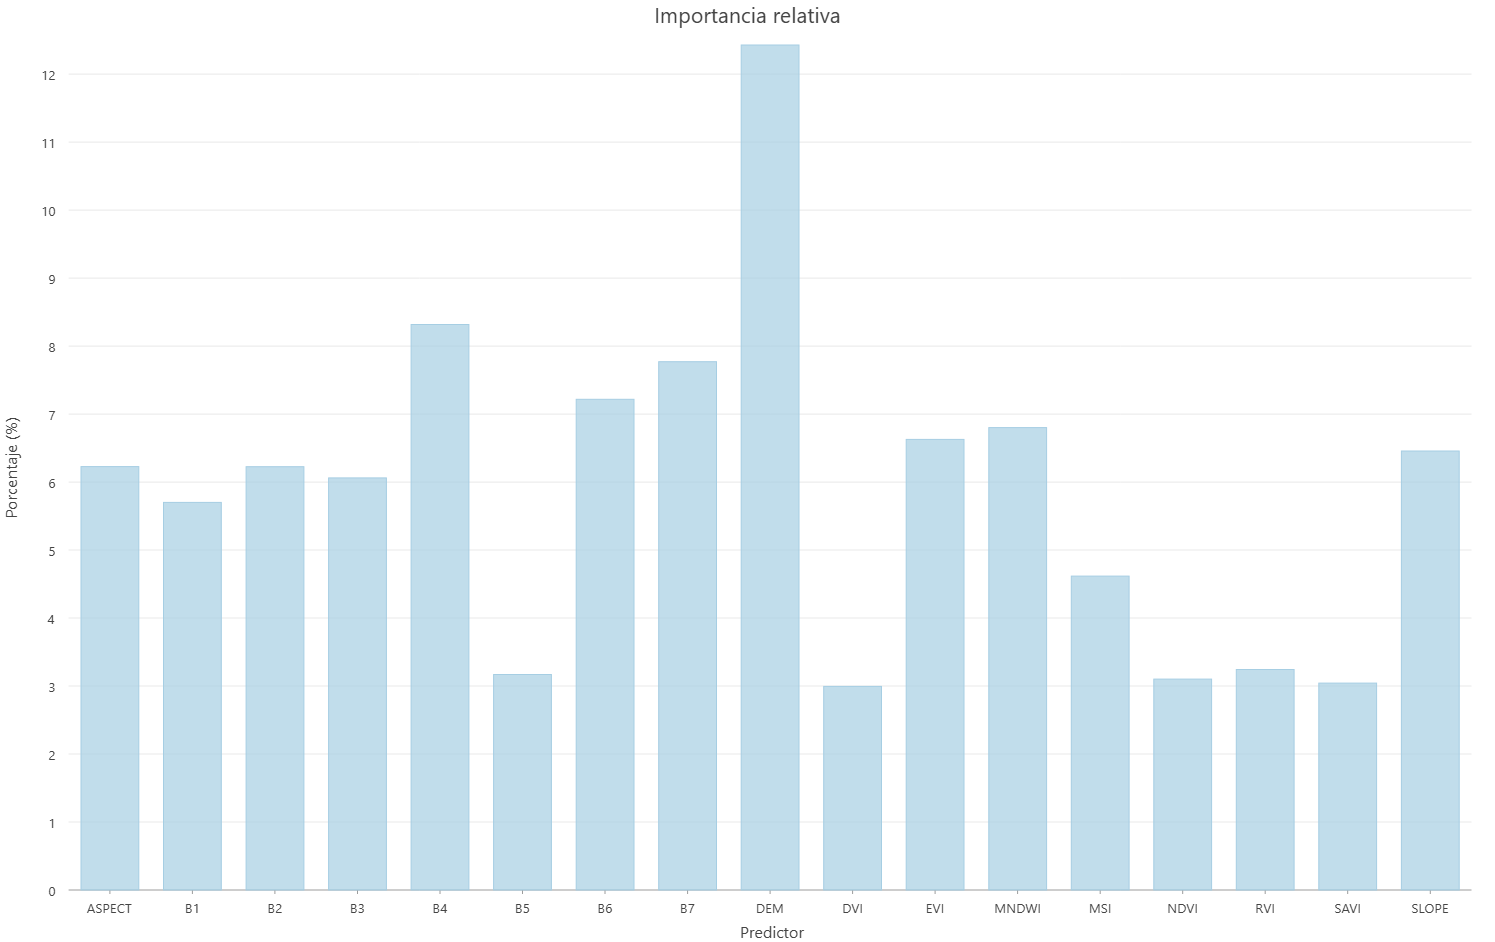

In [11]:
# Matplotlib es un complemento explícito, no sustituye mapas ni gráficos ArcGIS.
# Etapa de la práctica: entradas intactas; resultados en la carpeta de ejecución.
importance_fields = [f.name for f in arcpy.ListFields(str(importance_table)) if f.type not in {"OID", "Geometry"}]
importance_df_raw = table_to_df(importance_table, importance_fields)
display(importance_df_raw)

numeric_cols = [c for c in importance_df_raw.columns if c != "BEST_ITE"]
importance_long = (
    importance_df_raw.loc[[0], numeric_cols]
    .T
    .reset_index()
    .rename(columns={"index": "variable", 0: "importancia"})
    .sort_values("importancia", ascending=False)
)
importance_long["porcentaje"] = importance_long["importancia"] / importance_long["importancia"].sum() * 100
importance_long.to_csv(OUT / "clase_04_importancia_variables.csv", index=False, encoding="utf-8-sig")
display(importance_long)

fig, ax = plt.subplots(figsize=(9, 6))
importance_long.sort_values("porcentaje").plot.barh(x="variable", y="porcentaje", ax=ax, color="#2e7d32", legend=False)
ax.set_title("Importancia relativa de variables - Random Forest Coiba")
ax.set_xlabel("Importancia relativa (%)")
ax.set_ylabel("")
fig.tight_layout()
importance_png = OUT / "clase_04_importancia_variables.png"
fig.savefig(importance_png, dpi=160)
plt.show()
print(rel(importance_png))


top_vars = importance_long.head(5)[["variable", "porcentaje"]]
ndvi_row = importance_long.loc[importance_long["variable"] == "NDVI"]
ndvi_text = "NDVI no aparece en la tabla de importancia."
if not ndvi_row.empty:
    ndvi_text = f"NDVI quedó con {ndvi_row.iloc[0]['porcentaje']:.1f}% de importancia relativa en esta corrida."

interpretacion_importancia = "\n".join([
    "### Interpretación de importancia",
    "",
    "La tabla de importancia indica qué variables redujeron más el error del modelo forest-based en esta corrida. No debe leerse como causalidad.",
    "",
    "Variables con mayor peso relativo:",
    *[f"- **{row.variable}**: {row.porcentaje:.1f}%" for row in top_vars.itertuples()],
    "",
    ndvi_text,
    "",
    "Si NDVI queda bajo frente a bandas o variables topográficas, la lectura metodológica es revisar colinealidad, saturación del índice en vegetación densa y coherencia temporal con los puntos de biomasa, no eliminarlo automáticamente."
])
display(Markdown(interpretacion_importancia))

# Tabla larga de presentación para barras nativas; no altera la tabla del modelo.
bar_table = str(WORK_GDB / 'importancia_grafico')
arcpy.management.CreateTable(str(WORK_GDB), 'importancia_grafico')
arcpy.management.AddField(bar_table, 'Variable', 'TEXT', field_length=100)
arcpy.management.AddField(bar_table, 'Porcentaje', 'DOUBLE')
with arcpy.da.InsertCursor(bar_table, ['Variable','Porcentaje']) as cursor:
    for row in importance_long.itertuples():
        cursor.insertRow((row.variable,float(row.porcentaje)))
native_chart(arcpy.charts.Bar(x='Variable',y='Porcentaje',aggregation='SUM',dataSource=bar_table,title='Importancia relativa',xTitle='Predictor',yTitle='Porcentaje (%)'),'arcgis_importancia')


La tabla larga ordena los campos efectivamente devueltos por Forest; confirme etiquetas y valores numéricos antes de leer las cinco barras mayores y el mensaje sobre NDVI. `importancia_grafico` es una tabla derivada para presentación, no otro modelo. El porcentaje compara contribuciones dentro de esta corrida, no biomasa explicada ni causalidad. Predictores correlacionados pueden compartir importancia; un rango bajo no autoriza eliminar NDVI. La primera fila usada por el gráfico no es la fila «Best Iteration» del HTML: sus porcentajes no deben intercambiarse.


## 9.1 Lectura sustantiva de la importancia de variables

La importancia de variables muestra un modelo que no depende de una sola señal. La primera fila normalizada sitúa DEM (12,428%), B4 (8,317%), B7 (7,771%), B6 (7,217%), MNDWI (6,801%) y EVI (6,627%) al inicio. La tabla explica señales destacadas, no una clasificación causal:

| Variable | Lectura posible |
|---|---|
| `DEM` | Gradiente topográfico; puede representar condiciones ecológicas, humedad, exposición o estructura de vegetación asociada al relieve. |
| `B4` | Banda roja; sensible a absorción por clorofila y diferencias de cobertura vegetal. |
| `B6` | SWIR 1; aporta otro contraste de humedad y cobertura, correlacionado con otros predictores. |
| `B7` | SWIR 2; puede capturar humedad, estructura y diferencias en vegetación/suelo. |
| `MNDWI` | Señal relacionada con agua/humedad; puede estar actuando como proxy de condiciones de humedad o borde costero. |
| `Slope` | Pendiente; puede representar accesibilidad, drenaje, erosión o variación ecológica. |
| `EVI` | Índice de vegetación mejorado; suele responder mejor que NDVI en vegetación densa. |

### Qué implica que `DEM` sea la variable más importante

Que `DEM` aparezca primero no significa que la elevación “cause” directamente la biomasa. Significa que, en esta muestra, la elevación ayuda al modelo a separar mejor valores de `AGBD`. Puede estar actuando como variable proxy de:

- gradientes ecológicos;
- humedad disponible;
- exposición;
- accesibilidad humana;
- diferencias de composición o estructura del bosque.

### Qué implica que `NDVI` quede bajo

`NDVI` aparece con baja importancia relativa, alrededor de 3%. Esto no quiere decir que NDVI “no sirve”. Hay varias explicaciones plausibles:

1. **Saturación:** en vegetación densa, NDVI puede perder sensibilidad para diferenciar biomasa alta.
2. **Redundancia:** NDVI comparte información con bandas como rojo (`B4`) e infrarrojo cercano (`B5`) y con otros índices.
3. **Competencia entre variables correlacionadas:** Random Forest puede repartir importancia entre variables parecidas.
4. **Biomasa estructural:** `AGBD` depende de estructura vertical y densidad del bosque, no solo de vigor fotosintético superficial.
5. **Escala espacial:** el píxel de 30 m puede no coincidir perfectamente con la huella real de la observación de campo.

**Lectura recomendada:** NDVI no debe eliminarse por una sola corrida. Debe compararse en experimentos controlados: modelo con bandas, modelo con índices, modelo con topografía y modelo combinado.


## 10. Evaluar predicciones y residuales

Desde `rf_agbd_trained_features`, se comparan AGBD y PREDICTED y se calculan MAE = promedio de |observado − predicho|, RMSE = raíz del promedio del error al cuadrado, sesgo = promedio del residual y R² = 1 − suma de errores cuadrados / variación observada. La función presupone valores válidos y variación no nula en AGBD. Guarda métricas y gráficos de la capa resultante: no reconstruye la partición retenida del reporte Forest.


,valor
MAE,52.374470
RMSE,74.247486
Error medio,-1.948037
R2_aprox,0.766611


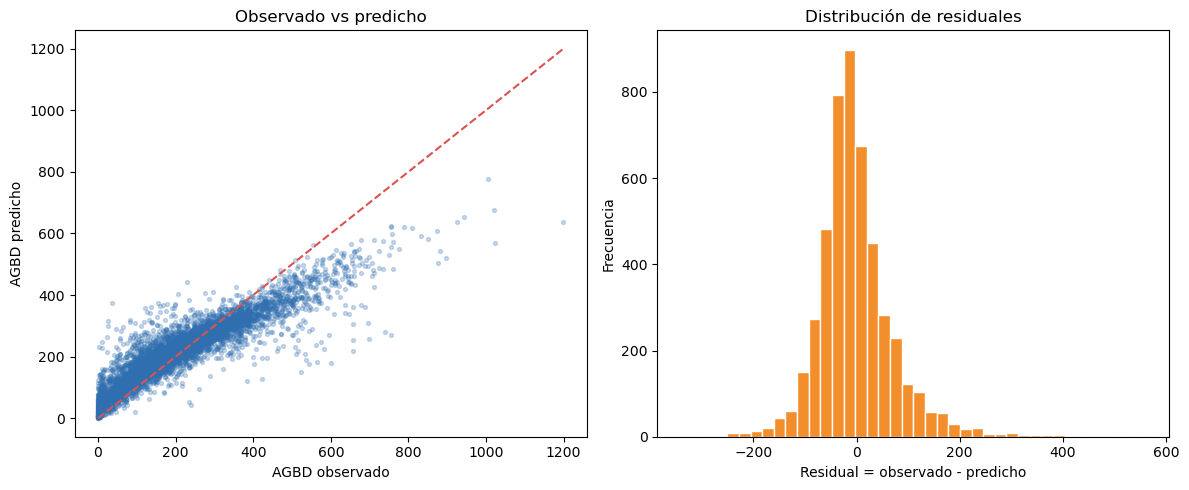

99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/clase_04_prediccion_residuales.png



### Interpretación de métricas y residuales

- **MAE**: 52.37. En promedio, el modelo se equivoca por esa magnitud de AGBD en los puntos usados por la salida entrenada.
- **RMSE**: 74.25. Al ser mayor que MAE, sugiere que hay errores grandes que conviene ubicar espacialmente.
- **Error medio**: -1.95. Valores cercanos a cero indican menor sesgo global, pero pueden ocultar sesgos locales.
- **R² aproximado sobre la capa entrenada**: 0.767. Esta lectura no reemplaza la validación reportada por ArcGIS ni una validación espacial por bloques.

La siguiente revisión obligatoria es el mapa de residuales: un modelo puede tener métricas aceptables y aun así fallar sistemáticamente en ciertos sectores de Coiba.


In [12]:
# Matplotlib es un complemento explícito, no sustituye mapas ni gráficos ArcGIS.
# Etapa de la práctica: entradas intactas; resultados en la carpeta de ejecución.
trained_fields = ["SOURCE_ID", TARGET_FIELD, "PREDICTED", "RESIDUAL", "STDRESID"] + model_fields
trained_df = table_to_df(trained_features, trained_fields)
trained_df.to_csv(OUT / "clase_04_predicciones_residuales.csv", index=False, encoding="utf-8-sig")

def regression_metrics(df, observed="AGBD", predicted="PREDICTED"):
    y = df[observed].astype(float)
    yhat = df[predicted].astype(float)
    residual = y - yhat
    mae = np.mean(np.abs(residual))
    rmse = np.sqrt(np.mean(residual ** 2))
    bias = np.mean(residual)
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return pd.Series({"MAE": mae, "RMSE": rmse, "Error medio": bias, "R2_aprox": r2})

metrics = regression_metrics(trained_df).to_frame("valor")
display(metrics)
metrics.to_csv(OUT / "clase_04_metricas_entrenamiento.csv", encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(trained_df[TARGET_FIELD], trained_df["PREDICTED"], s=8, alpha=0.25, color="#2f6fb0")
min_v = min(trained_df[TARGET_FIELD].min(), trained_df["PREDICTED"].min())
max_v = max(trained_df[TARGET_FIELD].max(), trained_df["PREDICTED"].max())
axes[0].plot([min_v, max_v], [min_v, max_v], color="#d9534f", linestyle="--")
axes[0].set_title("Observado vs predicho")
axes[0].set_xlabel("AGBD observado")
axes[0].set_ylabel("AGBD predicho")

axes[1].hist(trained_df["RESIDUAL"].dropna(), bins=40, color="#f28e2b", edgecolor="white")
axes[1].set_title("Distribución de residuales")
axes[1].set_xlabel("Residual = observado - predicho")
axes[1].set_ylabel("Frecuencia")

fig.tight_layout()
residual_png = OUT / "clase_04_prediccion_residuales.png"
fig.savefig(residual_png, dpi=160)
plt.show()
print(rel(residual_png))


interpretacion_metricas = f"""
### Interpretación de métricas y residuales

- **MAE**: {metrics.loc['MAE', 'valor']:.2f}. En promedio, el modelo se equivoca por esa magnitud de AGBD en los puntos usados por la salida entrenada.
- **RMSE**: {metrics.loc['RMSE', 'valor']:.2f}. Al ser mayor que MAE, sugiere que hay errores grandes que conviene ubicar espacialmente.
- **Error medio**: {metrics.loc['Error medio', 'valor']:.2f}. Valores cercanos a cero indican menor sesgo global, pero pueden ocultar sesgos locales.
- **R² aproximado sobre la capa entrenada**: {metrics.loc['R2_aprox', 'valor']:.3f}. Esta lectura no reemplaza la validación reportada por ArcGIS ni una validación espacial por bloques.

La siguiente revisión obligatoria es el mapa de residuales: un modelo puede tener métricas aceptables y aun así fallar sistemáticamente en ciertos sectores de Coiba.
"""
display(Markdown(interpretacion_metricas))


En observado frente a predicho, la diagonal indica igualdad; puntos debajo señalan subpredicción. En el histograma, residual positivo significa observado mayor que predicho. MAE/RMSE usan Mg/ha; R² es adimensional. RMSE es al menos MAE para el mismo conjunto: una separación marcada revela errores de magnitud desigual, no su ubicación. El sesgo global puede cancelar errores opuestos. Estas métricas calculadas sobre la capa de salida no son validación retenida y tampoco pertenecen al bosque raster.


## 10.1 Lectura de residuales: magnitud, signo y extremos

El [CSV de la capa resultante](../salidas_clase_04/publicados/clase_04_metricas_entrenamiento.csv) registra MAE **52,374470**, RMSE **74,247486**, error medio **−1,948037** y R² aproximado **0,766611**. No son métricas del subconjunto retenido: proceden de la capa de salida TRAIN. La media de observado menos predicho, ligeramente negativa, indica sobrepredicción global; errores positivos y negativos pueden cancelarse. RMSE mayor que MAE revela errores de magnitud desigual.

Compare la diagonal observado–predicho y las colas del histograma: debajo de la diagonal hay subestimación; encima, sobreestimación. Busque si las observaciones altas se predicen más cerca del centro, sin trasladar ejemplos numéricos de otra corrida. Una compresión de extremos afectaría decisiones sobre biomasa y carbono, pero una tabla global no localiza dónde ocurre. No elimine valores altos ni transforme AGBD automáticamente: revisar extremos, comparar configuraciones y validar espacialmente son estudios posteriores.


## 11. Mapear residuales como control geoespacial

El cursor lee XY y errores de `trained_features`, guarda `clase_04_residuales_xy.csv` y representa los puntos existentes, sin generar otra capa de predicción. Matplotlib usa STDRESID con límites simétricos dados por el percentil 98 de su magnitud absoluta; `native_map` representa RESIDUAL en ArcGIS con capas filtradas por signo y símbolos puntuales simples. Son dos escalas distintas del diagnóstico.

El mapa ArcGIS representa RESIDUAL en Mg/ha: rojo positivo indica subestimación y azul negativo sobrestimación (observado menos predicho, comprobado en los 4.840 registros). Dos capas usan la misma copia, con consultas RESIDUAL > 0 y RESIDUAL < 0; no hay ceros ni capa vacía de cero. El color distingue signo, no magnitud. El complemento Matplotlib conserva STDRESID, adimensional, con escala simétrica. Ninguno demuestra autocorrelación por sí solo.


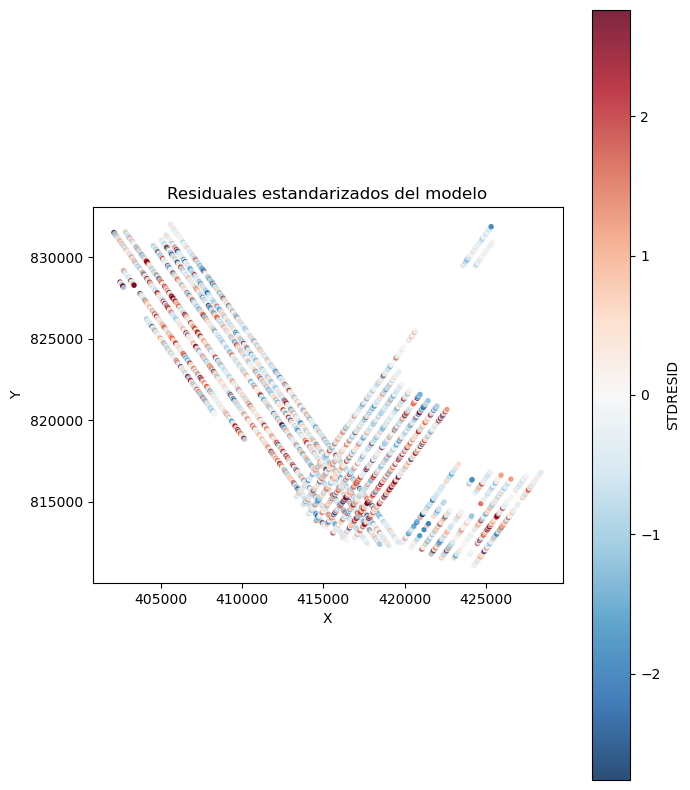

99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/clase_04_mapa_residuales.png



### Interpretación espacial de residuales

- Residual estandarizado mediano absoluto: 0.50.
- Percentil 95 del residual estandarizado absoluto: 2.02.
- Los puntos con colores intensos indican lugares donde el modelo se aleja más de la biomasa observada.

Si esos errores forman grupos espaciales, la señal no es solo estadística: puede faltar una variable ambiental, existir sombra/topografía no capturada, o haber sesgo en la distribución de puntos de entrenamiento.


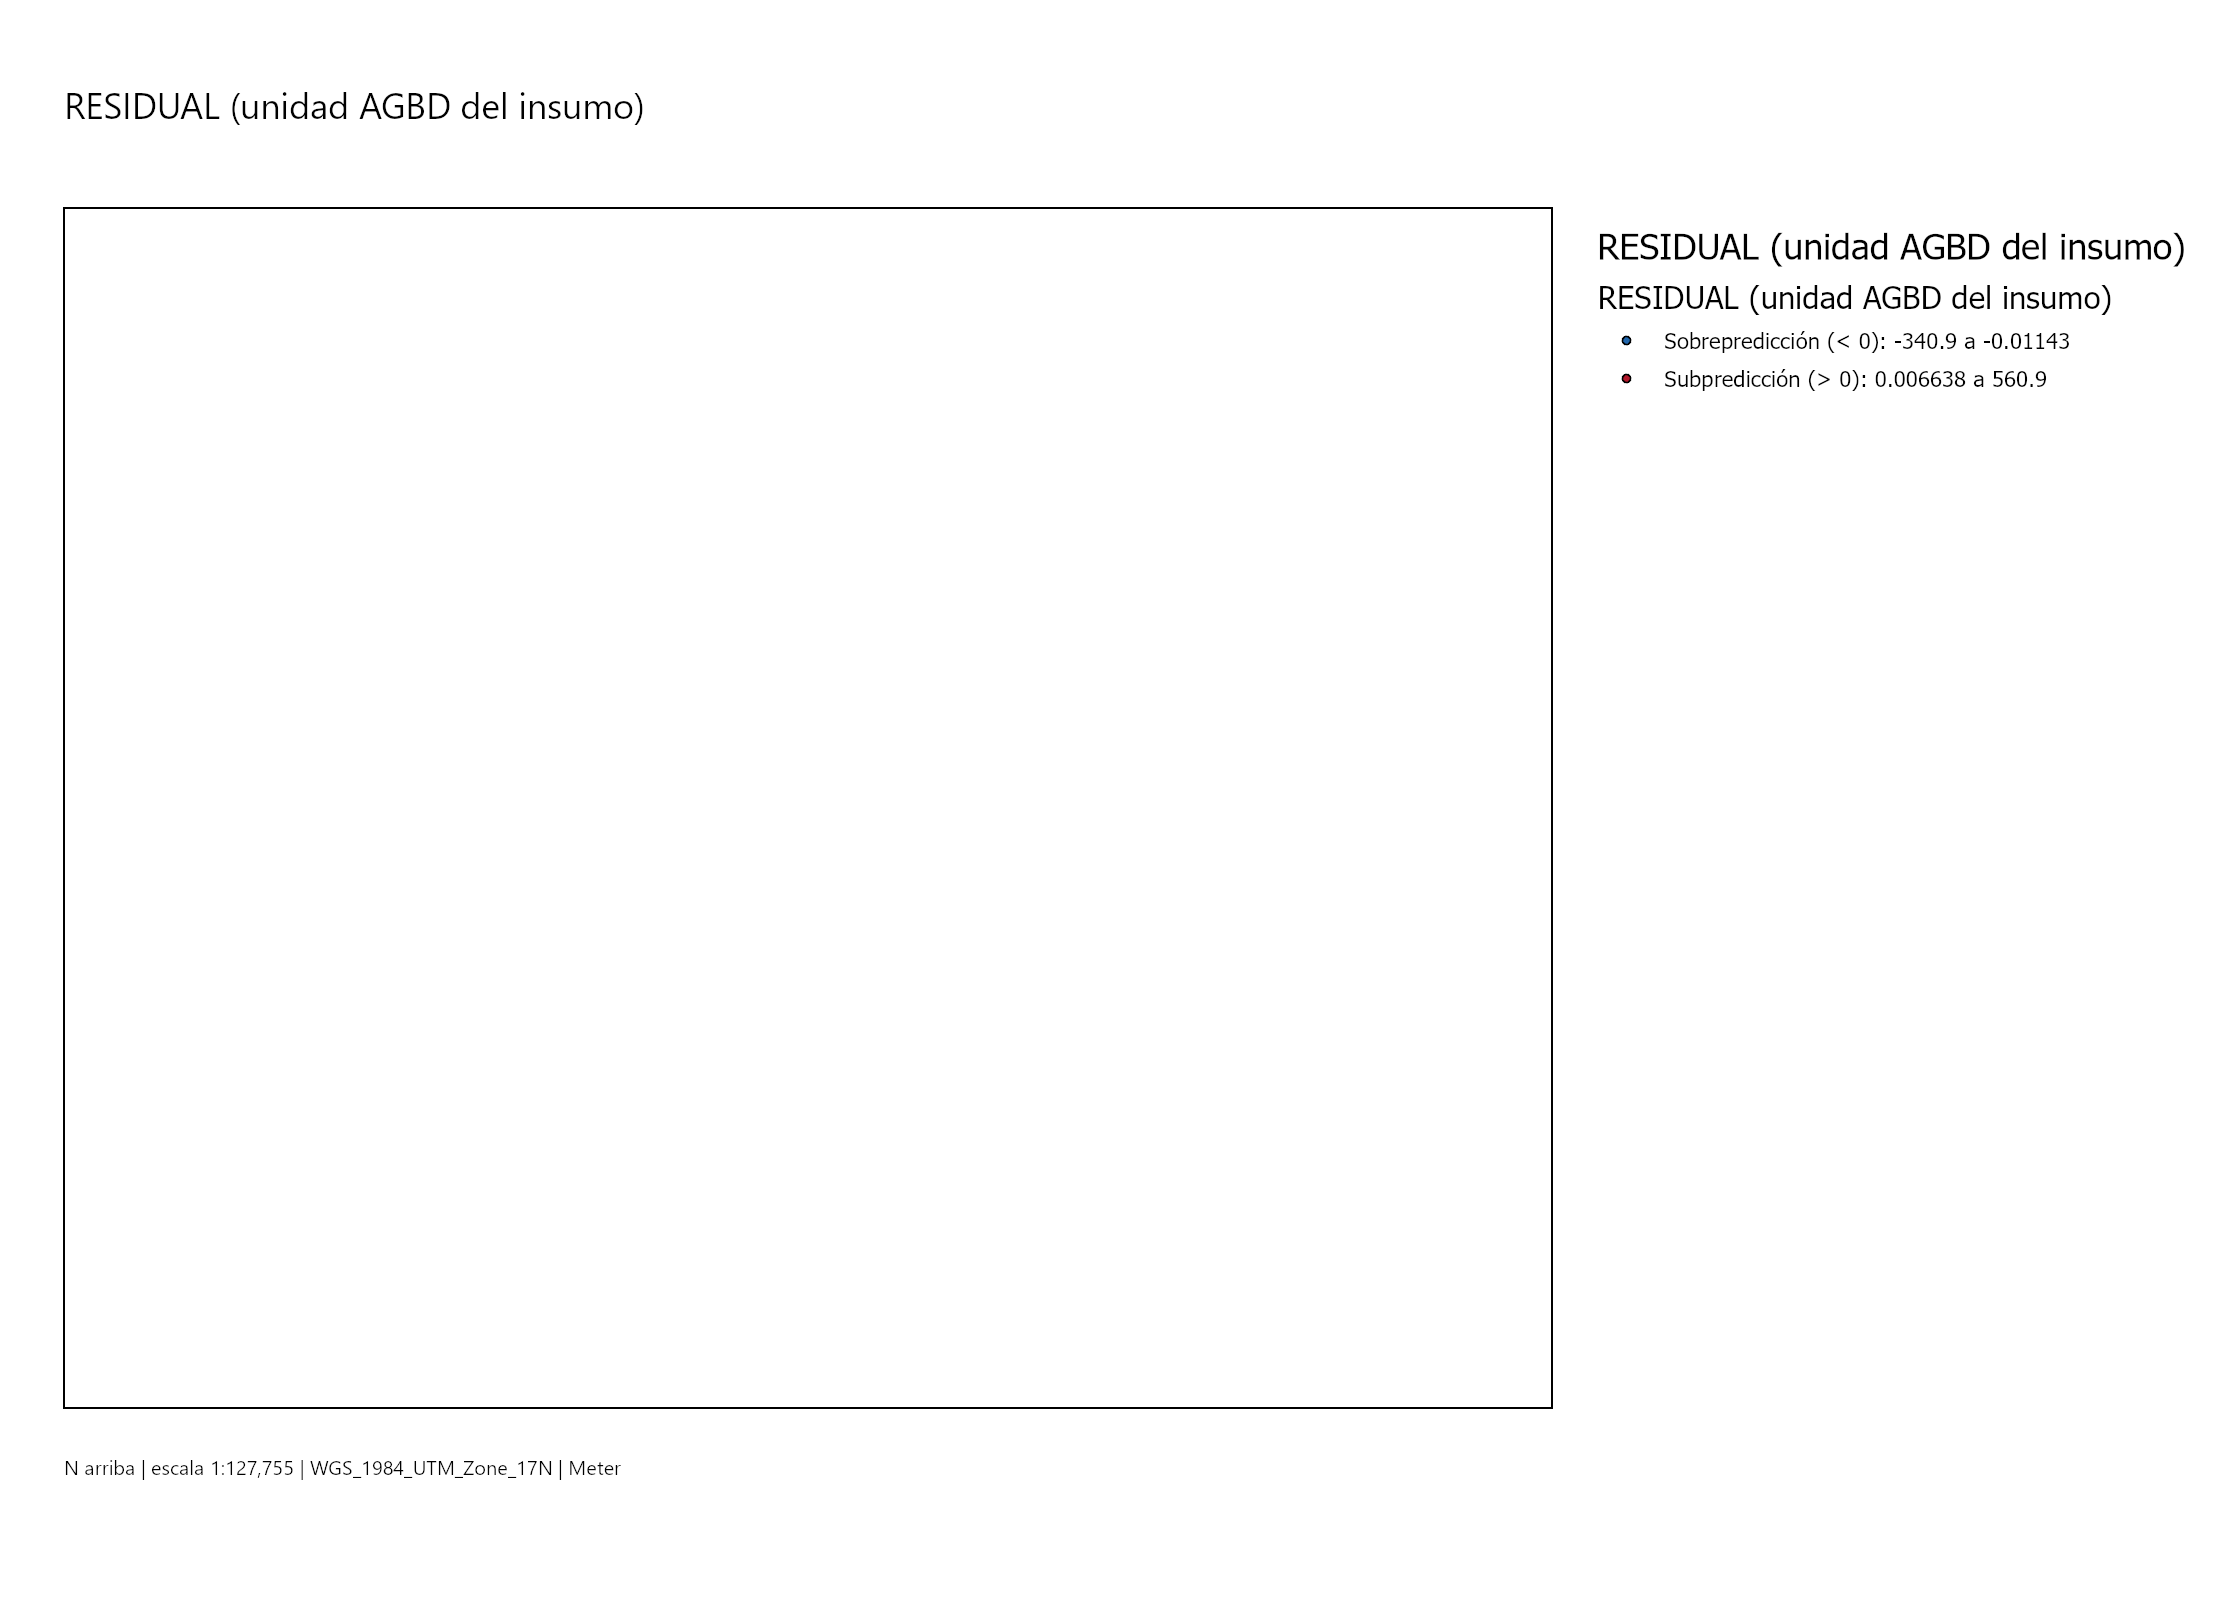

In [13]:
# Matplotlib es un complemento explícito, no sustituye mapas ni gráficos ArcGIS.
# Etapa de la práctica: entradas intactas; resultados en la carpeta de ejecución.
xy_fields = ["SHAPE@X", "SHAPE@Y", TARGET_FIELD, "PREDICTED", "RESIDUAL", "STDRESID"]
rows = []
with arcpy.da.SearchCursor(str(trained_features), xy_fields) as cursor:
    for x, y, obs, pred, resid, stdresid in cursor:
        rows.append({"x": x, "y": y, "AGBD": obs, "PREDICTED": pred, "RESIDUAL": resid, "STDRESID": stdresid})
map_df = pd.DataFrame(rows)
map_df.to_csv(OUT / "clase_04_residuales_xy.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(7, 8))
lim = np.nanpercentile(np.abs(map_df["STDRESID"]), 98)
sc = ax.scatter(map_df["x"], map_df["y"], c=map_df["STDRESID"], s=8, cmap="RdBu_r", vmin=-lim, vmax=lim, alpha=0.85)
ax.set_title("Residuales estandarizados del modelo")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_aspect("equal", adjustable="box")
plt.colorbar(sc, ax=ax, label="STDRESID")
fig.tight_layout()
map_png = OUT / "clase_04_mapa_residuales.png"
fig.savefig(map_png, dpi=170)
plt.show()
print(rel(map_png))


abs_resid = map_df["STDRESID"].abs()
interpretacion_mapa = f"""
### Interpretación espacial de residuales

- Residual estandarizado mediano absoluto: {abs_resid.median():.2f}.
- Percentil 95 del residual estandarizado absoluto: {abs_resid.quantile(0.95):.2f}.
- Los puntos con colores intensos indican lugares donde el modelo se aleja más de la biomasa observada.

Si esos errores forman grupos espaciales, la señal no es solo estadística: puede faltar una variable ambiental, existir sombra/topografía no capturada, o haber sesgo en la distribución de puntos de entrenamiento.
"""
display(Markdown(interpretacion_mapa))

native_map(trained_features, 'arcgis_residuales', 'RESIDUAL', 'Mg/ha')


### Mapa residual corregido — render focal sin reentrenamiento

![Residuales ArcGIS por signo, Mg/ha](../salidas_clase_04/publicados/arcgis_residuales.png)

Elaboración propia con ArcGIS Pro 3.6.2 a partir de una copia de la capa TRAIN existente. Azul: 2.859 sobrepredicciones; rojo: 1.981 subpredicciones; cero: 0. Rango −340,868 a 560,933 Mg/ha. Los puntos son visibles en franjas y cruces; ambos signos aparecen, sin que el color codifique la magnitud ni demuestre autocorrelación. El solapamiento impide contar visualmente cada registro. Todos los XY están dentro del marco UTM 17N.

La salida anterior de la celda se conserva como histórica: fue generada con otro helper y no corresponde al render corregido. Esta imagen adyacente procede exclusivamente de [comprobación focal](../salidas_clase_04/publicados/README.md); no acredita otra ejecución integral de 17/17.

Compare mediana y percentil 95 de |STDRESID| con los colores del complemento; los extremos que superan su límite cromático pueden compartir color y no deben confundirse con valores iguales. En el mapa corregido lea signo y rango total de RESIDUAL; el tamaño constante no representa la magnitud. Un PNG con leyenda pero sin puntos no permite concluir ausencia de error ni corrección del mapa histórico vacío.

## 11.1 Interpretación espacial y riesgos metodológicos

El mapa de residuales ayuda a responder una pregunta que las métricas globales no responden: **¿dónde falla el modelo?**

Si los errores grandes se agrupan espacialmente, la falla puede indicar procesos territoriales no capturados por las variables actuales. Algunas hipótesis plausibles son:

- efectos topográficos locales no resumidos por DEM, pendiente o aspecto;
- sombras, humedad o condiciones de imagen que afectan las bandas Landsat;
- estructura vertical del bosque no observable directamente con índices ópticos;
- puntos de campo con valores extremos que representan condiciones ecológicas particulares;
- partición de validación que no cubre bien todos los rangos ambientales.

### Cómo usar este mapa

No debe leerse solo como “mapa de errores”. Debe usarse para decidir dónde investigar:

1. Ubicar puntos con residuales estandarizados altos.
2. Revisar si coinciden con zonas de relieve, borde costero, sombra o transición de cobertura.
3. Comparar esos puntos con los rangos de DEM, EVI, B4, B7 y MNDWI.
4. Decidir si faltan variables explicativas o si hay observaciones atípicas que requieren control de calidad.

**Lectura de fondo:** en GeoIA, la validación no termina en una tabla. Un modelo puede tener un desempeño promedio aceptable y aun así fallar territorialmente donde más importa.


## 12. Síntesis interpretativa para comunicar el resultado

Esta práctica permite decir algo metodológicamente sólido, sin sobrerreclamar el resultado:

> Se construyó una primera aproximación de estimación de biomasa aérea en Coiba usando Random Forest con ArcPy. El flujo integró puntos de biomasa observada, bandas Landsat, índices espectrales y variables topográficas. La corrida muestra que el modelo aprende patrones en entrenamiento, pero la diferencia entre entrenamiento y validación indica que todavía no debe usarse como producto final. La importancia de variables sugiere una combinación de señales topográficas y espectrales, con DEM, B4, B7, MNDWI, pendiente y EVI como variables destacadas. NDVI aparece bajo, pero no debe descartarse sin revisar redundancia, saturación y colinealidad. La compresión de valores altos debe examinarse en los diagnósticos puntuales, por lo que se recomienda mejorar la validación, revisar extremos y probar configuraciones alternativas antes de generar una superficie final confiable.

### Qué diría en una presentación

- El flujo técnico está funcionando: ArcPy permite preparar puntos, extraer rasters, entrenar el modelo y revisar diagnósticos.
- El resultado es una **corrida exploratoria**, no un mapa final.
- La brecha entrenamiento-validación es la alerta principal.
- La importancia de variables sugiere que la biomasa responde a una combinación de relieve, bandas e índices, no solo a NDVI.
- Revise errores en valores altos: su magnitud puede afectar decisiones de conservación o carbono.
- La siguiente fase debe enfocarse en validación espacial, más corridas y sensibilidad de variables.

### Próximas pruebas recomendadas

1. Aumentar árboles: 100, 300 o 500.
2. Comparar modelos por grupos de variables:
   - solo bandas Landsat;
   - bandas + índices;
   - bandas + topografía;
   - bandas + índices + topografía.
3. Probar transformación `log(AGBD + 1)` para reducir dominancia de extremos.
4. Hacer validación espacial por bloques o por zonas de la isla.
5. Revisar puntos con residuales absolutos altos.
6. Evaluar colinealidad entre índices y bandas.
7. Revisar EVI por valores extremos antes de depender de su importancia.
8. Generar raster final solo después de mejorar validación y documentar límites de extrapolación.

### Referencias para interpretar esta salida

- ArcGIS Pro recomienda revisar diagnósticos de entrenamiento, validación, out-of-bag, importancia y rangos de variables explicativas.
- Breiman (2001) fundamenta Random Forest como ensamble de árboles que reduce varianza, pero no elimina la necesidad de validación independiente.
- En teledetección, NDVI es una señal útil de vigor vegetal, pero puede saturarse en vegetación densa; para biomasa aérea suelen ser útiles combinaciones con SWIR, topografía y otras variables ambientales.


## 13. Predicción raster exploratoria: un nuevo ajuste

¿Cómo pasar de AGBD observada en puntos a una estimación por celda? La rama siguiente vuelve a entrenar con `training_fc` y los mismos 17 rasters de `RASTER_SPECS`, todos numéricos. No carga el SSM de TRAIN ni utiliza sus campos como variables explicativas: la llamada recibe exclusivamente `explanatory_rasters`. Se conservan los hiperparámetros, 10% retenido y dos validaciones para una comparación exploratoria; no se fija una semilla nueva. El reajuste final con 0% retenido recomendado por Esri no se realiza aquí. Sus diagnósticos, importancia y SSM quedan separados de TRAIN.

Fuente: Esri, ArcGIS Pro 3.6, [How Forest-based… works — Predict using a model / Predicting to rasters](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/how-forest-works.htm) y [Forest — Python Parameters](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/forestbasedclassificationregression.htm), pasajes verificados el 2026-09-21. Los rasters continuos se interpolan bilinealmente. El dominio depende de su solapamiento y NoData, no de un límite administrativo. Sin configuración explícita se usaría el tamaño de celda mayor; aquí la cuadrícula se fija con NDVI real.

### 13.1 Inspeccionar antes de elegir la cuadrícula
La siguiente celda solo inspecciona entradas y prepara rutas: no predice. Requiere las etapas anteriores, Spatial Analyst y `training_fc` completo. Registra tamaño, extensión y CRS de cada raster; detiene CRS/GCS/datum desconocidos o distintos. No presupone 30 metros ni cobertura de toda Coiba. Los 17 predictores mantienen el ejercicio, no son una selección óptima ni causal.


In [14]:
# Inspección de solo lectura; las rutas absolutas siguen válidas al cambiar workspace.
raster_reference = str((SOURCE_GDB / 'NDVI_Mask').resolve())
raster_sr = arcpy.Describe(raster_reference).spatialReference
raster_identity = gcs_identity(raster_sr, 'Cuadricula NDVI')
# ValueTable nativa: GPBoolean 'false' = Categorical desmarcado (continuo), distinto del objetivo NUMERIC.
raster_pairs = [[str((SOURCE_GDB / name).resolve()), 'false'] for name, _, _ in RASTER_SPECS]
if len(raster_pairs) != 17 or not arcpy.Exists(training_fc):
    raise ValueError('Se requieren los 17 rasters y la seleccion de entrenamiento.')
grid_rows = []
for raster_path, kind in raster_pairs:
    raster = arcpy.Raster(raster_path)
    if gcs_identity(raster.spatialReference, Path(raster_path).name) != raster_identity:
        raise ValueError('GCS/datum incompatible: no elegir una transformacion automaticamente.')
    if raster.bandCount != 1 or raster.meanCellWidth <= 0 or raster.meanCellHeight <= 0:
        raise ValueError('Se esperaba un raster de una banda con celda positiva.')
    e = raster.extent
    grid_rows.append({'raster': Path(raster_path).name, 'CRS': raster.spatialReference.name,
                      'celda_x': raster.meanCellWidth, 'celda_y': raster.meanCellHeight,
                      'columnas': raster.width, 'filas': raster.height,
                      'extension': (e.XMin, e.YMin, e.XMax, e.YMax)})
display(pd.DataFrame(grid_rows))
print('Referencia:', raster_sr.name, '| unidades:', raster_sr.linearUnitName if raster_sr.type == 'Projected' else raster_sr.angularUnitName)
raster_output = str(WORK_GDB / 'rf_agbd_prediction')
raster_trained_fc = str(WORK_GDB / 'rf_raster_trained_features')
raster_importance = str(WORK_GDB / 'rf_raster_importance')
raster_model = str(OUT / 'rf_raster_coiba.ssm')


Cuadricula NDVI | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984


LC09_20230222_B1_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
LC09_20230222_B2_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
LC09_20230222_B3_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
LC09_20230222_B4_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984


LC09_20230222_B5_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
LC09_20230222_B6_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
LC09_20230222_B7_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984


NDVI_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
EVI_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
SAVI_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
MNDWI_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984


MSI_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984
RVI_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984


DVI_Mask | CRS: WGS_1984_UTM_Zone_17N | GCS: 4326 | datum: D_WGS_1984


DEM_30_Mask | CRS: GCS_WGS_1984 | GCS: 4326 | datum: D_WGS_1984
Slope_DEM_30 | CRS: GCS_WGS_1984 | GCS: 4326 | datum: D_WGS_1984


Aspect_DEM_30 | CRS: GCS_WGS_1984 | GCS: 4326 | datum: D_WGS_1984


,raster,CRS,celda_x,celda_y,columnas,filas,extension
0,LC09_20230222_B1_Mask,WGS_1984_UTM_Zone_17N,30.000000,30.000000,1108,1227,"(401565.0, 808845.0, 434805.0, 845655.0)"
1,LC09_20230222_B2_Mask,WGS_1984_UTM_Zone_17N,30.000000,30.000000,1108,1227,"(401565.0, 808845.0, 434805.0, 845655.0)"
2,LC09_20230222_B3_Mask,WGS_1984_UTM_Zone_17N,30.000000,30.000000,1108,1227,"(401565.0, 808845.0, 434805.0, 845655.0)"
3,LC09_20230222_B4_Mask,WGS_1984_UTM_Zone_17N,30.000000,30.000000,1108,1227,"(401565.0, 808845.0, 434805.0, 845655.0)"
4,LC09_20230222_B5_Mask,WGS_1984_UTM_Zone_17N,30.000000,30.000000,1108,1227,"(401565.0, 808845.0, 434805.0, 845655.0)"
5,LC09_20230222_B6_Mask,WGS_1984_UTM_Zone_17N,30.000000,30.000000,1108,1227,"(401565.0, 808845.0, 434805.0, 845655.0)"
6,LC09_20230222_B7_Mask,WGS_1984_UTM_Zone_17N,30.000000,30.000000,1108,1227,"(401565.0, 808845.0, 434805.0, 845655.0)"
7,NDVI_Mask,WGS_1984_UTM_Zone_17N,30.000000,30.000000,1108,1227,"(401565.0, 808845.0, 434805.0, 845655.0)"
8,EVI_Mask,WGS_1984_UTM_Zone_17N,30.000000,30.000000,1108,1227,"(401565.0, 808845.0, 434805.0, 845655.0)"
9,SAVI_Mask,WGS_1984_UTM_Zone_17N,30.000000,30.000000,1108,1227,"(401565.0, 808845.0, 434805.0, 845655.0)"


Referencia: WGS_1984_UTM_Zone_17N | unidades: Meter


Compare las resoluciones y CRS de la tabla: una proyección distinta con el mismo GCS/datum no significa que las extensiones numéricas sean directamente comparables. La llamada siguiente deja que ArcGIS gestione la cuadrícula de análisis con referencia NDVI, `snapRaster`, `cellSize` y CRS explícitos; `MINOF` limita la extensión al solapamiento de entradas. La tabla registra 14 rasters UTM y tres topográficos geográficos, con GCS WGS 1984/datum compatibles. La salida queda alineada con NDVI y tiene una extensión reducida por el solapamiento. Inspeccionar las entradas no prueba cobertura ni compatibilidad temporal.

### 13.2 Reentrenar para predecir a raster

Esta celda sí ajusta un bosque nuevo y escribe la predicción, la capa de entrenamiento, la importancia y el SSM exclusivamente en OUT/WORK_GDB nuevos. También aísla workspace y scratchWorkspace: no genera salidas en Datos_Coiba.gdb. Los mensajes HTML pertenecen a esta rama; no les atribuya las métricas anteriores de TRAIN.


In [15]:
# PREDICT_RASTER reentrena con rasters; no reutiliza el SSM ni explanatory_variables de TRAIN.
with arcpy.EnvManager(workspace=str(WORK_GDB), scratchWorkspace=str(WORK_GDB),
                      snapRaster=raster_reference, cellSize=raster_reference,
                      outputCoordinateSystem=raster_sr, extent='MINOF'):
    raster_result = arcpy.stats.Forest(
        prediction_type='PREDICT_RASTER', in_features=str(training_fc),
        variable_predict=TARGET_FIELD, treat_variable_as_categorical='NUMERIC',
        explanatory_rasters=raster_pairs, output_raster=raster_output,
        output_trained_features=raster_trained_fc, output_importance_table=raster_importance,
        number_of_trees=30, minimum_leaf_size=5, maximum_depth=20,
        sample_size=100, random_variables=5, percentage_for_training=10,
        number_validation_runs=2, output_trained_model=raster_model, model_type='FOREST-BASED')
    raster_messages = raster_result.getMessages()
raster_html = forest_messages_to_html(raster_messages)
(OUT / 'clase_04_raster_diagnostico_arcgis.html').write_text(raster_html, encoding='utf-8')
display(HTML(raster_html))
print('Raster:', rel(raster_output), '| importancia:', rel(raster_importance))
print('Capa:', rel(raster_trained_fc), '| SSM:', rel(raster_model))


Raster: 99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/clase_04_coiba_rf.gdb/rf_agbd_prediction | importancia: 99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/clase_04_coiba_rf.gdb/rf_raster_importance
Capa: 99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/clase_04_coiba_rf.gdb/rf_raster_trained_features | SSM: 99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/rf_raster_coiba.ssm


El [reporte propio de la rama raster](../salidas_clase_04/publicados/clase_04_raster_diagnostico_arcgis.html) registra entrenamiento R² **0,891**, MAE **46,639**, RMSE **62,661**; validación retenida R² **0,219**, MAE **101,354**, RMSE **133,425**. La brecha sigue siendo amplia: generar una superficie no resuelve la débil generalización. El reporte marca `+` en **los 17 predictores**: los rangos de predicción exceden los representados en entrenamiento. Esto advierte extrapolación, no identifica por sí solo cuáles píxeles son fiables. El 10% retenido y las dos corridas no son validación espacial independiente; diferencias pequeñas respecto a TRAIN no prueban mejora controlada.

### 13.3 Medir la salida, sin confundir NoData con cero

Se leerán todas las celdas del raster generado (las entradas locales tienen aproximadamente 1,3 millones de píxeles); una guarda detiene salidas mayores de diez millones para no consumir memoria inesperada. IsNull identifica NoData por separado, y NumPy cuenta valores finitos, no finitos y ceros válidos. La tabla informa rango y cuantiles reales, no supuestos. La máscara derivada se guarda solo en WORK_GDB.


In [16]:
# Leer solo la prediccion nueva; IsNull separa ausencia de dato de cero valido.
prediction = arcpy.Raster(raster_output)
pixel_count = int(prediction.width) * int(prediction.height)
if prediction.bandCount != 1 or not 0 < pixel_count <= 10_000_000:
    raise ValueError('Salida inesperada: revisar bandas/tamano antes de cargarla en memoria.')
null_output = str(WORK_GDB / 'rf_raster_nodata')
with arcpy.EnvManager(workspace=str(WORK_GDB), scratchWorkspace=str(WORK_GDB),
                      snapRaster=raster_output, cellSize=raster_output,
                      outputCoordinateSystem=prediction.spatialReference, extent=prediction.extent):
    arcpy.sa.IsNull(prediction).save(null_output)
    pixel_values = arcpy.RasterToNumPyArray(prediction).astype(np.float64)
    nodata_mask = arcpy.RasterToNumPyArray(null_output).astype(bool)
if pixel_values.shape != nodata_mask.shape:
    raise ValueError('Mascara NoData y prediccion no coinciden.')
finite_mask = (~nodata_mask) & np.isfinite(pixel_values)
finite_values = pixel_values[finite_mask]
nonfinite_count = int(((~nodata_mask) & ~np.isfinite(pixel_values)).sum())
e = prediction.extent
raster_summary = {
    'CRS': prediction.spatialReference.name, 'columnas': prediction.width, 'filas': prediction.height,
    'celda_x': prediction.meanCellWidth, 'celda_y': prediction.meanCellHeight,
    'extension': (e.XMin, e.YMin, e.XMax, e.YMax), 'tipo_pixel': prediction.pixelType,
    'total': pixel_count, 'NoData': int(nodata_mask.sum()), 'finitos': int(finite_values.size),
    'no_finitos_sin_NoData': nonfinite_count, 'ceros_validos': int((finite_values == 0).sum()),
    'minimo': float(finite_values.min()) if finite_values.size else None,
    'maximo': float(finite_values.max()) if finite_values.size else None,
    'media': float(finite_values.mean()) if finite_values.size else None}
display(pd.DataFrame([raster_summary]).T.rename(columns={0: 'valor'}))
pd.DataFrame([raster_summary]).to_csv(OUT / 'clase_04_raster_propiedades.csv', index=False)
if finite_values.size == 0 or nonfinite_count:
    raise ValueError('Raster sin valores finitos o con no finitos inesperados: revisar antes de dibujar.')
display(pd.Series(np.quantile(finite_values, [0, .05, .5, .95, 1]),
                  index=['min', 'p05', 'mediana', 'p95', 'max'], name='AGBD predicha'))


,valor
CRS,WGS_1984_UTM_Zone_17N
columnas,1099
filas,1222
celda_x,30.0
celda_y,30.0
extension,"(401745.0, 808935.0, 434715.0, 845595.0)"
tipo_pixel,F64
total,1342978
NoData,800972
finitos,542006


min          0.934559
p05         74.362793
mediana    236.810373
p95        348.490965
max        687.265558
Name: AGBD predicha, dtype: float64

La salida F64 tiene **1.099 columnas × 1.222 filas**, celda **30 × 30 m observada**, CRS **WGS 1984 UTM 17N** y extensión **(401745, 808935, 434715, 845595)**. Se cumple **1.342.978 = 542.006 finitos + 800.972 NoData**, con **0 ceros válidos y 0 otros no finitos**. Mínimo **0,934559**, máximo **687,265558**, media **227,702455**; mediana **236,810373**. Son estadísticas de la superficie, no medidas de exactitud. NoData significa ausencia de predicción, no biomasa cero; los ceros válidos se cuentan aparte. Compare la celda y el CRS resultantes con NDVI, y el rango con AGBD observada: una salida finita no garantiza plausibilidad ecológica. Mínimo/máximo y cuantiles corresponden a toda la salida válida, pero no miden exactitud. La extensión rectangular incluye huecos y no prueba cobertura administrativa.

### 13.4 Mapa e histograma ArcGIS de la predicción

La siguiente celda crea un mapa raster independiente del auxiliar residual pendiente, con RasterStretchColorizer público, leyenda, escala numérica y CRS. La firma/properties se contrastaron en los archivos instalados de ArcGIS Pro `_symbology.pyi` y `_colorizer.pyi`; el mapa y el histograma exportados son visibles en la ejecución integrada. Para el histograma se crea una tabla de hasta 50.000 valores realmente predichos: selección determinista de índices equiespaciados en el vector de píxeles finitos, orden de lectura por filas. No es una muestra aleatoria ni una validación del modelo. Se utiliza `arcpy.charts.Histogram` y el auxiliar existente `native_chart`, no Matplotlib como sustituto.


Histograma: 50000 valores de 542006 pixeles finitos; indices equiespaciados.


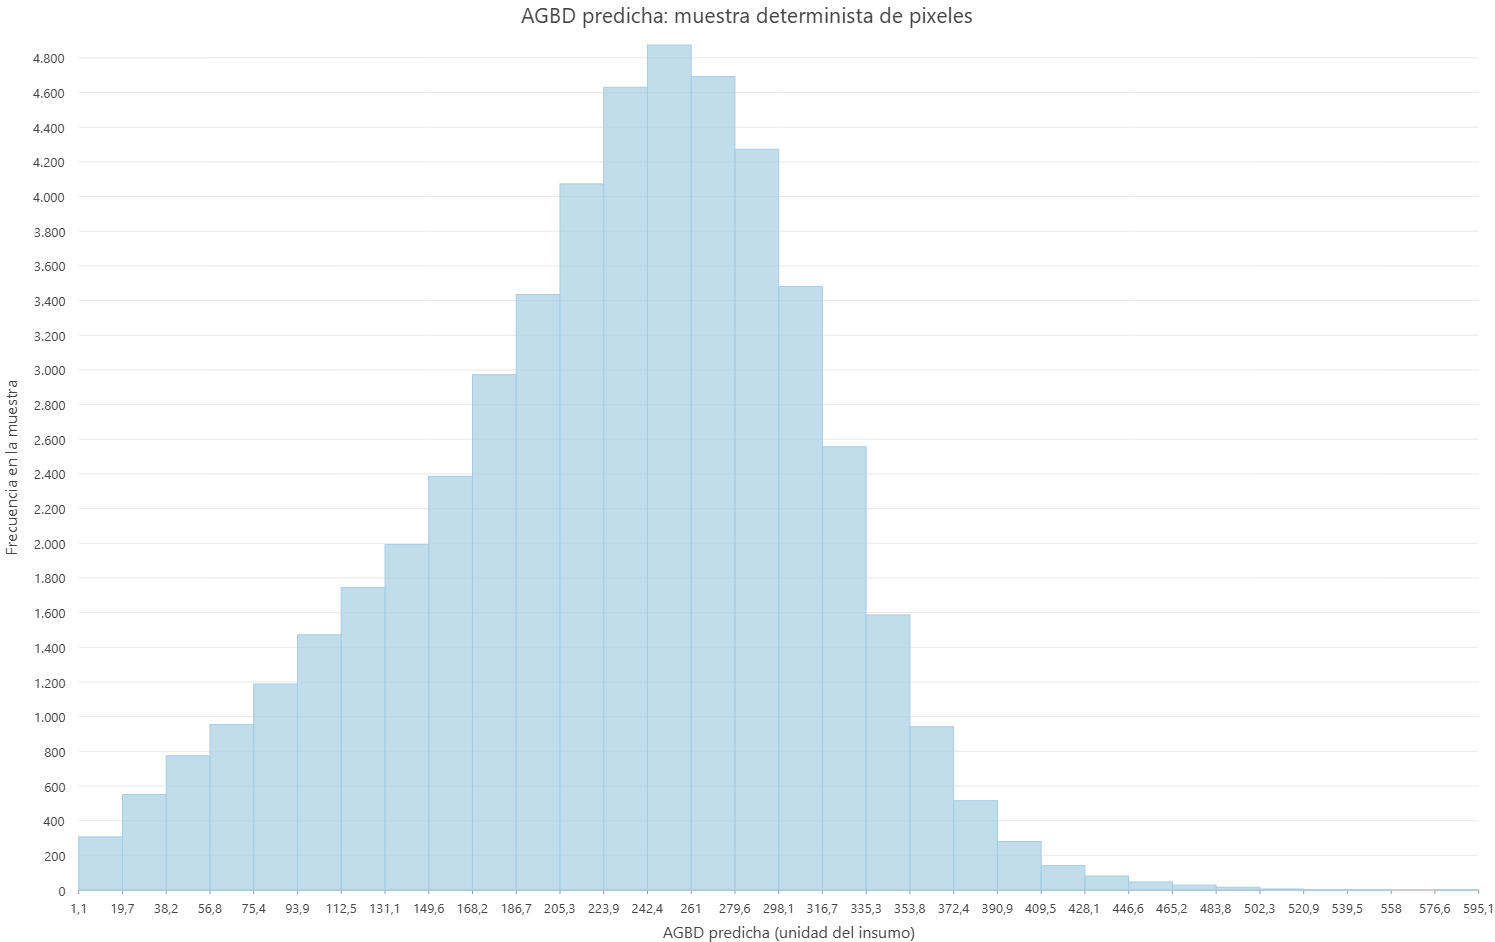

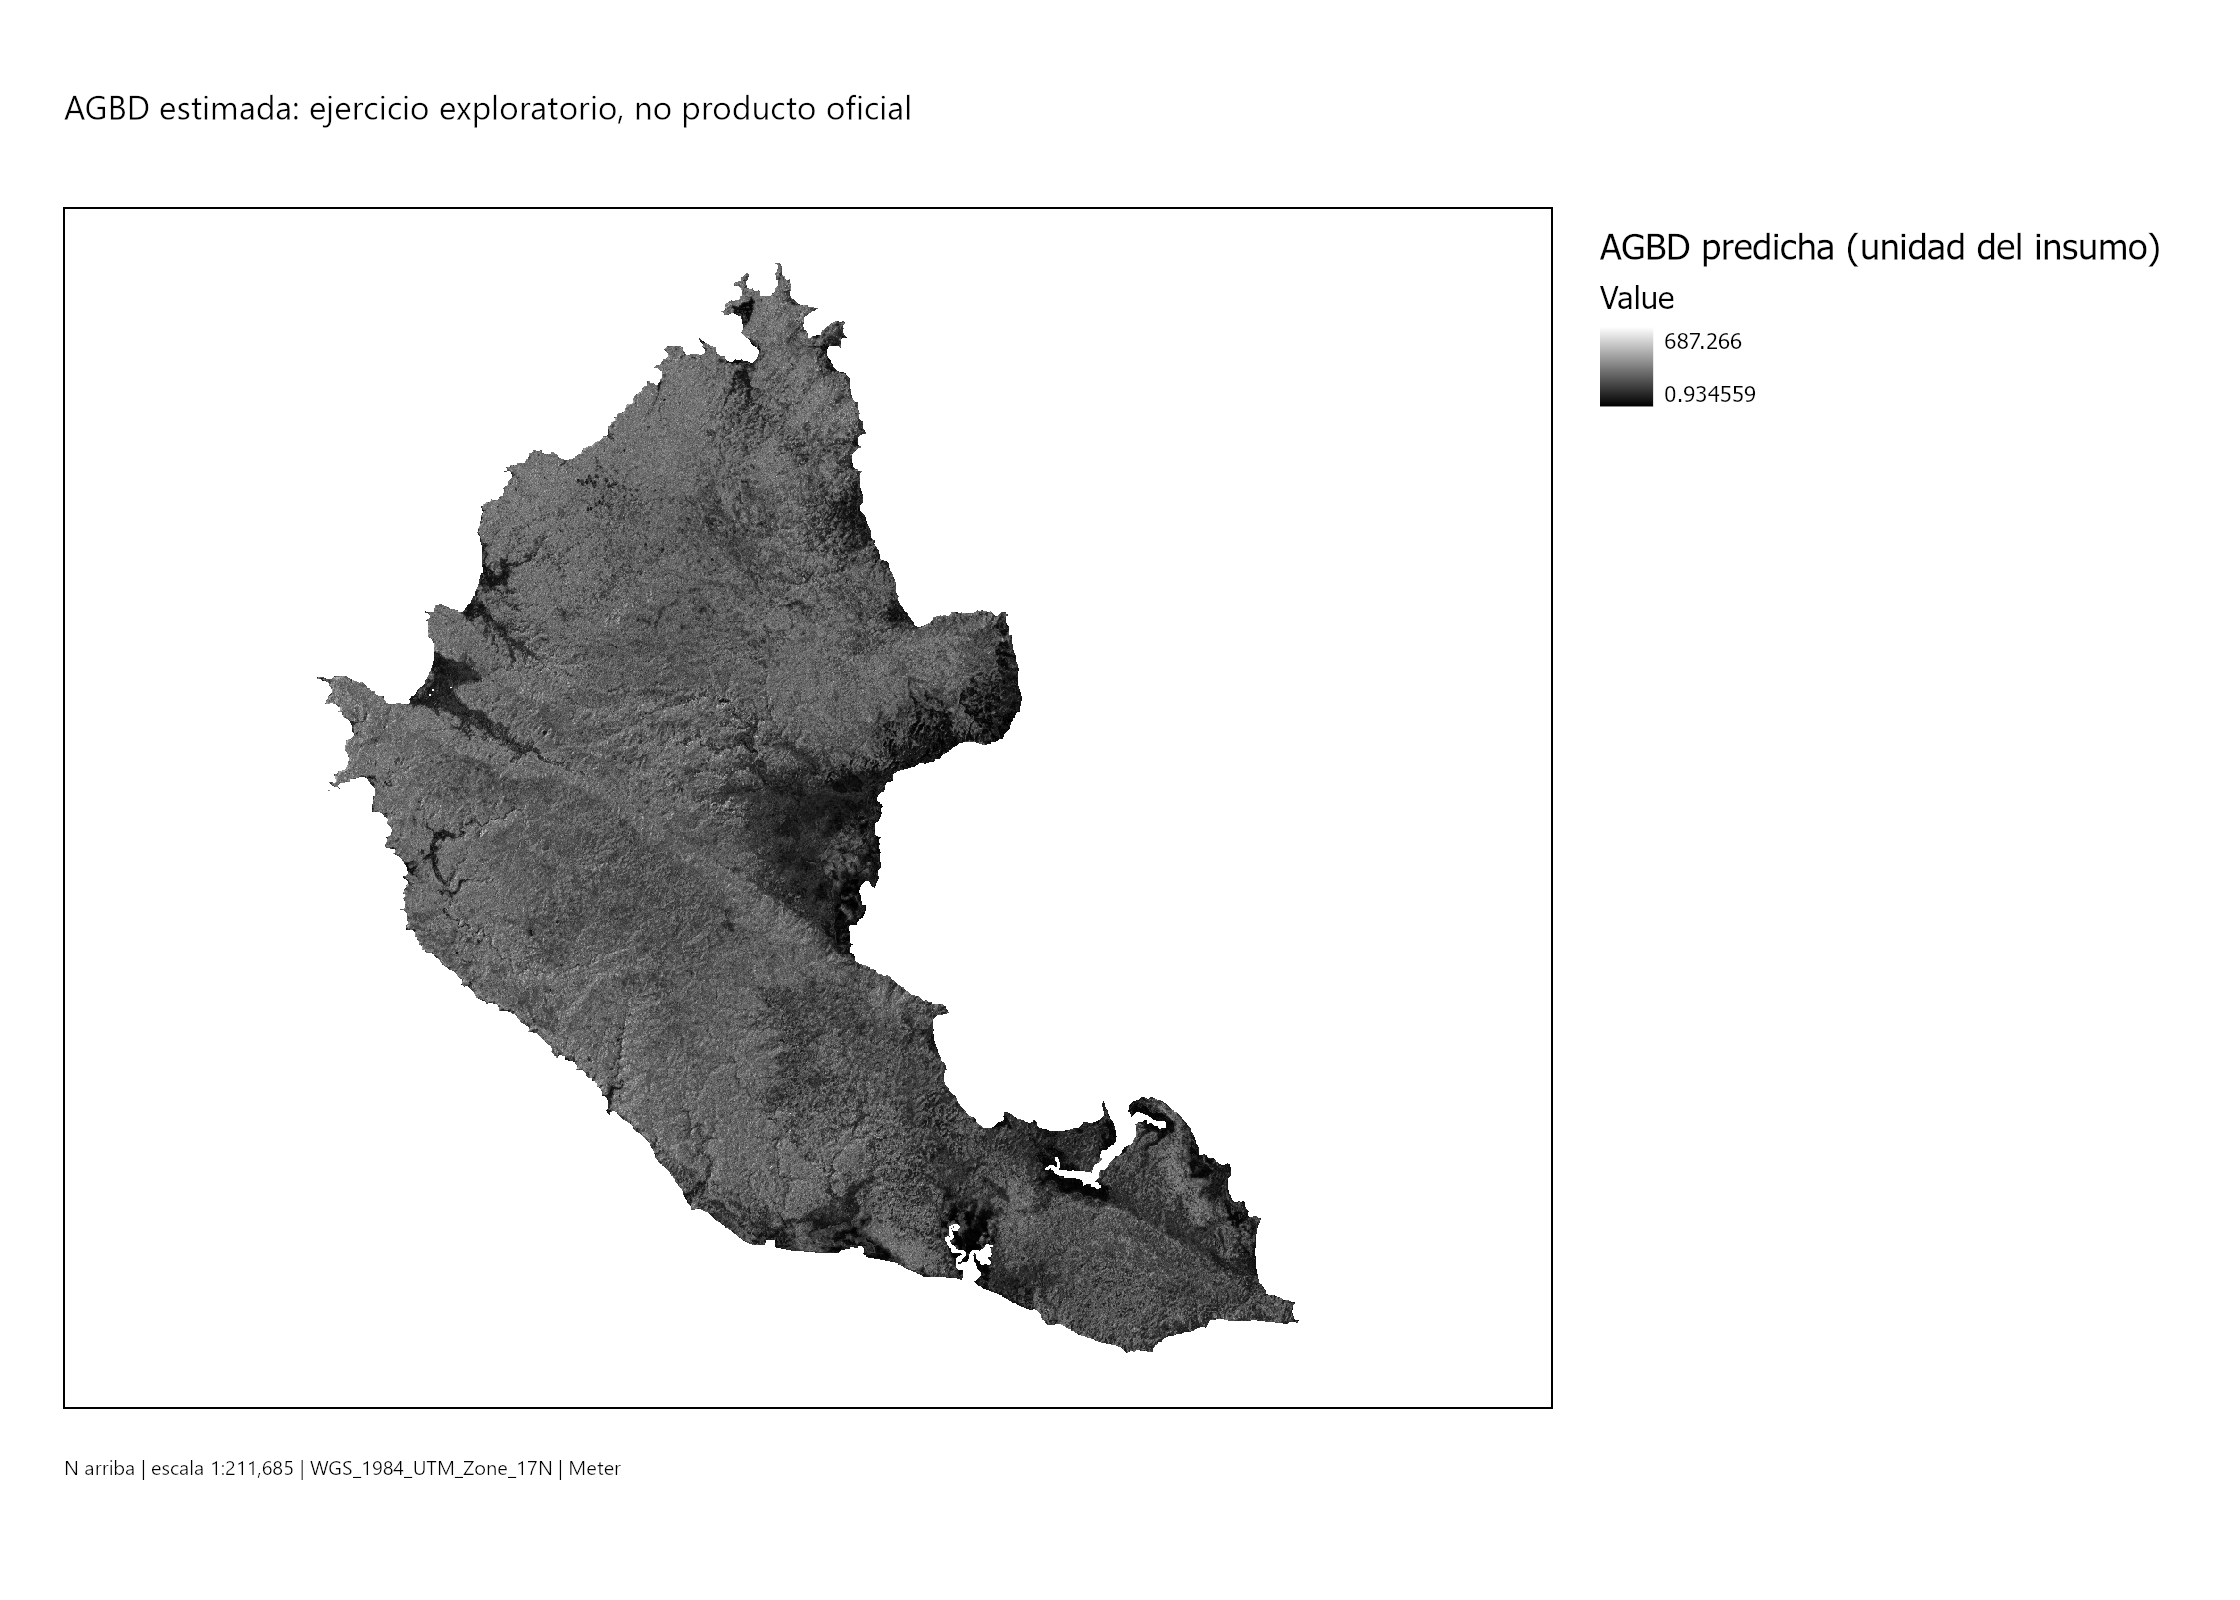

Inspeccion visual pendiente: comprobar superficie, leyenda y huecos en 99 - Recursos/salidas_clase_04/practica_01/ejecucion_0199c4565df24da99d4dcc2588490c81/arcgis_raster_agbd.png


In [17]:
# Tabla derivada solo en WORK_GDB: muestra determinista, sin cambiar el raster.
sample_size_pixels = min(50_000, int(finite_values.size))
sample_indices = np.linspace(0, finite_values.size - 1, sample_size_pixels, dtype=np.int64)
hist_table = str(WORK_GDB / 'rf_raster_histogram_values')
arcpy.management.CreateTable(str(WORK_GDB), 'rf_raster_histogram_values')
arcpy.management.AddField(hist_table, 'AGBD_PRED', 'DOUBLE')
with arcpy.da.InsertCursor(hist_table, ['AGBD_PRED']) as cursor:
    for value in finite_values[sample_indices]:
        cursor.insertRow((float(value),))
print('Histograma:', sample_size_pixels, 'valores de', finite_values.size, 'pixeles finitos; indices equiespaciados.')
native_chart(arcpy.charts.Histogram(
    x='AGBD_PRED', dataSource=hist_table, title='AGBD predicha: muestra determinista de pixeles',
    xTitle='AGBD predicha (Mg/ha)', yTitle='Frecuencia en la muestra'), 'arcgis_raster_histograma')
# Mapa nuevo: no usa native_map ni su renderer de residuales.
raster_map = project.createMap('AGBD raster exploratorio', 'MAP')
for base_layer in raster_map.listLayers():
    raster_map.removeLayer(base_layer)
raster_map.spatialReference = prediction.spatialReference
raster_layer = raster_map.addDataFromPath(raster_output)
raster_layer.name = 'AGBD predicha (Mg/ha)'
raster_sym = raster_layer.symbology
raster_sym.updateColorizer('RasterStretchColorizer')
raster_sym.colorizer.stretchType = 'MinimumMaximum'
raster_sym.colorizer.gamma = 1.0
ramps = project.listColorRamps('Yellow to Green')
if ramps:
    raster_sym.colorizer.colorRamp = ramps[0]
raster_layer.symbology = raster_sym
if raster_layer.symbology.colorizer.type != 'RasterStretchColorizer':
    raise RuntimeError('No se conservo el colorizador raster esperado.')
raster_layout = project.createLayout(14, 10, 'INCH', 'Prediccion raster')
raster_frame = raster_layout.createMapFrame(rect(.4, 1.2, 9.7, 8.7), raster_map, 'Raster')
raster_frame.camera.setExtent(prediction.extent)
raster_frame.camera.scale *= 1.1
raster_legend = raster_layout.createMapSurroundElement(
    rect(10, 1.3, 13.7, 8.6), 'LEGEND', raster_frame, None, 'Leyenda raster')
raster_legend.fittingStrategy = 'AdjustFontSize'
project.createTextElement(raster_layout, arcpy.Point(.4, 9.2), 'POINT',
                          'AGBD estimada: ejercicio exploratorio, no producto oficial', 15, 'Segoe UI', 'Regular')
raster_units = prediction.spatialReference.linearUnitName if prediction.spatialReference.type == 'Projected' else prediction.spatialReference.angularUnitName
raster_footer = f'N arriba | escala 1:{raster_frame.camera.scale:,.0f} | {prediction.spatialReference.name} | {raster_units}'
project.createTextElement(raster_layout, arcpy.Point(.4, .75), 'POINT', raster_footer, 9, 'Segoe UI', 'Regular')
project.save()
raster_png = OUT / 'arcgis_raster_agbd.png'
raster_layout.exportToPNG(str(raster_png), resolution=160)
display(Image(filename=str(raster_png), width=1000))
print('Inspeccion visual pendiente: comprobar superficie, leyenda y huecos en', rel(raster_png))


Lea el mapa con su leyenda: el estiramiento mínimo–máximo representa valores continuos, no clases de exactitud. Observe huecos y bordes junto con la máscara NoData; la escala y el CRS describen la representación, no su validez científica. El histograma cuenta píxeles muestreados en intervalos de AGBD predicha: no observaciones de campo, áreas independientes ni casos de prueba retenidos. Compare distribución y rango con la tabla completa antes de interpretar extremos; la selección sistemática puede omitir patrones y valores raros.

**Lectura observada:** la superficie exportada está en **escala de grises**, con valores bajos oscuros y altos claros según su leyenda; los huecos sin predicción no equivalen a biomasa cero. Yellow to Green es una elección opcional de la guía, no el color observado. El histograma nativo legible representa **50.000 píxeles finitos seleccionados sistemáticamente**: predominan intervalos centrales alrededor de 240–280, con una cola derecha poco frecuente. La muestra no reproduce necesariamente los extremos de los 542.006 valores finitos ni permite inferir exactitud. Fuente: mapa e histograma ArcGIS enlazados en la procedencia final. El mensaje automático «Inspección visual pendiente» se conserva como salida original; la inspección posterior comprobó superficie, leyenda, huecos e histograma, sin corregir el mapa residual.


## Guía de la práctica en ArcGIS Pro — paso a paso

Esta guía permite reconocer en la interfaz las operaciones de las etapas de código 1–13; **no exige volver a ejecutar herramientas para demostrar que se leyó la guía**. El notebook sigue siendo autónomo. Si ya dispone de una ejecución, abra sus resultados y su historial; use Run únicamente al reproducir deliberadamente en otra carpeta nueva. La ejecución previa documentada fue ArcPy, no una secuencia de clics GUI; la rama raster también fue ejecutada mediante ArcPy, no mediante clics manuales.

Compatibilidad: los cinco bloques Mermaid requieren un frontend con soporte Mermaid; no se instalaron componentes. Los cinco diagramas actuales pasaron parser, renderizado e inspección de capturas mediante Chrome DevTools MCP y Mermaid 11.12.0 en una página about:blank aislada: etiquetas y flechas legibles, sin recortes. Esto no verifica su disposición nativa en Jupyter, ArcGIS Notebook u Obsidian.

### Insumos locales de esta práctica

Todos los insumos necesarios están en `99 - Recursos/datos/clase_04/Datos_Coiba.gdb`: una clase de puntos y los 17 rasters de la tabla del paso 6. **No necesita copiar datos, crear otra carpeta de entradas ni obtener CSV históricos.** Conecte esta GDB local. El notebook tampoco depende de auxiliares externos: `Blank.aprx` es una plantilla instalada de ArcGIS Pro, no un dataset que deba copiarse.

Para Python, inicie el kernel desde este vault o una subcarpeta: la primera celda busca `99 - Recursos` en el directorio actual y sus ancestros. Si no lo encuentra, corrija el directorio de inicio antes de ejecutar; si usa otra ubicación, configure las rutas de la primera celda (`DATA_DIR` apunta a la carpeta que contiene `Datos_Coiba.gdb`, no a la GDB). No cambie las celdas de análisis ni añada pasos GUI obligatorios al notebook.

| Entrada/campo | Qué se puede interpretar y comprobar |
|---|---|
| `AGBD_Observaciones_2023_Coiba` | 4.946 puntos; CRS verificado `GCS_WGS_1984`. Coordenadas geográficas no son distancias en metros. |
| `OBJECTID` / `Shape` | Identificador del registro y geometría; una copia puede reasignar OBJECTID. No deduplicar por semejanza de coordenadas. |
| `lon`, `lat` (Double) | Campos de longitud y latitud; contraste rangos con geometría, sin sustituirla ni reproyectar cambiando números. |
| `Time` (Date) | Campo temporal: revise rango y nulos; el nombre del dataset no demuestra cobertura temporal completa. |
| `AGBD` (Double) | Respuesta continua de biomasa aérea. Unidades y producto de origen no acreditados por metadatos locales. Cero no es NULL. |
| `Trajectory` (Integer) | Código presente, significado no documentado. No atribuir órbita o haz ni incorporarlo como predictor. |
| Siete bandas, siete índices y tres rasters topográficos | Nombres y significados docentes en la tabla del paso 6. Revise CRS, datum, resolución, extensión y NoData; no deduzca unidades físicas solo del nombre. |

La fuente inmediata es esta GDB local. Los metadatos de puntos solo aportan el título `AGBD_Observaciones_2023_Coiba_cDatos`; resumen, descripción, créditos y etiquetas están vacíos. No se atribuye un producto GEDI. La unidad docente Mg/ha corresponde a la confirmación del usuario indicada en la práctica, no a esos metadatos. Consulte [procedencia y evidencia local](../datos/clase_04/README.md); ninguna ruta histórica es una entrada de ejecución.

**Salidas GUI.** Cree una carpeta nueva, por ejemplo `99 - Recursos/salidas_clase_04/practica_01/manual_unique`, y elija otro nombre si ya existe. La llamaremos **carpeta de resultados**. La **GDB de trabajo** será `99 - Recursos/salidas_clase_04/practica_01/manual_unique/clase_04_coiba_rf.gdb`. `GDB de trabajo/nombre` significa seleccionar esa GDB y escribir el nombre indicado, no una ruta literal. Nunca sobrescriba una ejecución anterior.

**Comprobación de cada paso.** Abra la herramienta en **Analysis > Tools**, rellene Parameters y los Environments indicados; pulse **Run** y consulte **Analysis > History > herramienta > View Details > Messages**. Ante error, entrada ausente, salida preexistente, CRS desconocido o conteo inesperado, detenga ese paso: no borre registros, repare geometrías ni cambie hiperparámetros. Los conteos citados son referencias ArcPy, no garantías de otra ejecución ni evidencia de clics realizados aquí. Requiere Pro 3.6 y Spatial Analyst disponibles; si faltan, no continúe ni instale componentes.

### A. Abrir, reconocer y proteger los insumos · etapas 1–4

```mermaid
flowchart TD
  A["Proyecto y conexión de carpeta"] --> B["Catalog: GDB de entrada en solo lectura"]
  B --> C["Propiedades: campos, CRS y rasters"]
  C --> D["Vista Data Engineering: nulos y distribución"]
  D --> E["GDB nueva y copia para EDA"]
```

Siga el orden de arriba abajo: conocer la fuente precede a copiarla. La conexión de carpeta no vuelve inmutable la GDB; solo lectura es la regla de uso, no un permiso que esta guía configure. Data Engineering es una **vista**, no una herramienta `arcpy.DataEngineering`, y sus resúmenes no validan el modelo.

1. Para reproducir por interfaz, abra **ArcGIS Pro > New Project > Map**, nombre `coiba_manual`, ubicación en la carpeta de resultados nueva, y pulse **OK**. Para solo inspeccionar una ejecución, abra su `coiba_resultados.aprx` sin ejecutar herramientas. En **Catalog > Folders > Add Folder Connection**, conecte `99 - Recursos/datos/clase_04`; expanda `Datos_Coiba.gdb`. No edite su esquema, campos ni valores. Añada los puntos y `NDVI_Mask` al mapa con clic derecho > **Add To Current Map**. En Catalog, Properties de `AGBD_Observaciones_2023_Coiba` y de los rasters permite revisar CRS, extensión, resolución y tipos. La tabla de atributos aporta nombres reales; no suponga un EPSG o unidades AGBD. En Contents, clic derecho en la capa > **Data Engineering**: seleccione los campos, agréguelos al panel de estadísticas y pulse **Calculate** para revisar conteos, nulos y rangos disponibles. No ejecute transformaciones sobre la fuente. Repita esta inspección en `agbd_eda` del paso 4, conservando nulos y extremos.

2. **Analysis > Tools > Create File Geodatabase** (`CreateFileGDB`, etapa 1): Output Folder = la carpeta de resultados `99 - Recursos/salidas_clase_04/practica_01/manual_unique`; Name = `clase_04_coiba_rf.gdb`; versión por defecto. Cree la carpeta desde Catalog si reproduce por GUI. **Run** y compruebe la GDB vacía en esa carpeta, no en datos. En Catalog, clic derecho en la GDB nueva > **Make Default**; no confunda la GDB inicial del proyecto con esta GDB de trabajo.

3. **Analysis > Tools > Get Count** (`GetCount`, etapas 2 y 6): Input Rows = `Datos_Coiba.gdb/AGBD_Observaciones_2023_Coiba` sin selección para el inventario; después `GDB de trabajo/complete_case_training` para el entrenamiento. **Run** y lea Row Count/Messages. Es una salida escalar, sin dataset ni ruta nueva; una selección activa puede cambiar qué se cuenta. Repita solo si necesita reproducir el conteo de otra feature class del inventario. 4.946 es el conteo ArcPy integrado, no una ejecución manual de esta guía.

4. **Analysis > Tools > Copy Features** (`CopyFeatures`, etapa 4): Input Features = `Datos_Coiba.gdb/AGBD_Observaciones_2023_Coiba`; Output Feature Class = `GDB de trabajo/agbd_eda`; sin selección ni cambio de geometría. **Run** e inspeccione cantidad, AGBD y CRS de la copia. En Contents, clic derecho en `agbd_eda` > **Create Chart > Histogram**, Number = AGBD; **Symbology > Graduated Colors**, Field = AGBD. Use **Zoom To Layer** y compruebe puntos visibles y leyenda coherente. El histograma y el mapa son acciones de gráficos/simbología, no GP adicional. Compare nulos y ceros, concentración y colas; no borre extremos.

### B. De rasters a campos, sin borrar observaciones · etapas 5–6

```mermaid
flowchart TD
  A["Comparar CRS, GCS y datum reales"] --> B{"Identificados y mismo GCS y datum"}
  B -->|"No"| C["Detener: decidir referencia o transformación"]
  B -->|"Sí"| D["Project: nueva copia de puntos"]
  D --> E["Extract Multi Values to Points: BILINEAR"]
  E --> F["Seleccionar 18 valores no nulos"]
  F --> G["Copy Features: subconjunto completo"]
```

La rama de detención protege de transformaciones adivinadas. La otra permite extraer valores de rasters con proyecciones distintas pero GCS/datum compatibles. La selección conserva todos los puntos en la copia proyectada; copiar el subconjunto no significa eliminar los restantes. CRS compatible no implica igual resolución ni fecha.

5. **Analysis > Tools > Project** (`Project`, etapa 5): Input Dataset = `Datos_Coiba.gdb/AGBD_Observaciones_2023_Coiba`; Output Dataset = `GDB de trabajo/agbd_observaciones_proyectadas`; Output Coordinate System = importar de `Datos_Coiba.gdb/NDVI_Mask`. Geographic Transformation no se fija en el código: continúe solo después de su comprobación de GCS/datum iguales; si falla, deténgase. Otros parámetros por defecto. **Run**; inspeccione CRS y cantidad de puntos resultantes, sin asumir metros o EPSG por el nombre.

6. **Analysis > Tools > Extract Multi Values to Points** (`ExtractMultiValuesToPoints`, etapa 5): Input Point Features = exclusivamente `GDB de trabajo/agbd_observaciones_proyectadas`; Input Rasters y Output Field Names = las 17 filas siguientes; Bilinear interpolation activada (`BILINEAR`). **Run**. Esta herramienta modifica esa copia de puntos, no ofrece otra ruta de salida; nunca use aquí la fuente. Inspeccione los 17 campos agregados, rangos y nulos antes de entrenar; deben mantenerse los 4.946 puntos. Si faltan campos o cambia el conteo, deténgase y no repita la extracción sobre la misma copia.

Todos los rasters siguientes están dentro de `99 - Recursos/datos/clase_04/Datos_Coiba.gdb`. La columna campo se usa para extracción y TRAIN; PREDICT_RASTER recibe el raster, **no ese campo**. La correspondencia reproduce `RASTER_SPECS` sin renombrar entradas.

| Raster de entrada | Campo extraído / TRAIN | Tipo para PREDICT_RASTER | Significado docente |
|---|---|---|---|
| `LC09_20230222_B1_Mask` | `B1` | `false` / continuo | Banda Landsat 9 - coastal/aerosol |
| `LC09_20230222_B2_Mask` | `B2` | `false` / continuo | Banda Landsat 9 - azul |
| `LC09_20230222_B3_Mask` | `B3` | `false` / continuo | Banda Landsat 9 - verde |
| `LC09_20230222_B4_Mask` | `B4` | `false` / continuo | Banda Landsat 9 - rojo |
| `LC09_20230222_B5_Mask` | `B5` | `false` / continuo | Banda Landsat 9 - infrarrojo cercano |
| `LC09_20230222_B6_Mask` | `B6` | `false` / continuo | Banda Landsat 9 - SWIR 1 |
| `LC09_20230222_B7_Mask` | `B7` | `false` / continuo | Banda Landsat 9 - SWIR 2 |
| `NDVI_Mask` | `NDVI` | `false` / continuo | Índice de vegetación normalizado |
| `EVI_Mask` | `EVI` | `false` / continuo | Índice de vegetación mejorado |
| `SAVI_Mask` | `SAVI` | `false` / continuo | Índice de vegetación ajustado al suelo |
| `MNDWI_Mask` | `MNDWI` | `false` / continuo | Índice de agua modificado |
| `MSI_Mask` | `MSI` | `false` / continuo | Índice de estrés hídrico |
| `RVI_Mask` | `RVI` | `false` / continuo | Ratio vegetation index |
| `DVI_Mask` | `DVI` | `false` / continuo | Difference vegetation index |
| `DEM_30_Mask` | `DEM` | `false` / continuo | Elevación |
| `Slope_DEM_30` | `Slope` | `false` / continuo | Pendiente |
| `Aspect_DEM_30` | `Aspect` | `false` / continuo | Aspecto |

7. **Analysis > Tools > Make Feature Layer** (`MakeFeatureLayer`, etapa 6): Input Features = `GDB de trabajo/agbd_observaciones_proyectadas`; Output Layer = `coiba_complete_case_training`; sin expresión inicial. **Run**; compruebe que la capa referencia la copia, no la GDB fuente. Es una capa temporal, no un nuevo archivo.

8. **Analysis > Tools > Select Layer By Attribute** (`SelectLayerByAttribute`, etapa 6): Input Rows = `coiba_complete_case_training`; Selection Type = New selection (`NEW_SELECTION`). Use la expresión siguiente (el código aplica delimitadores propios del workspace). **Run**; inspeccione número seleccionado frente al total y la localización de lo no seleccionado, sin pulsar Delete.

```sql
AGBD IS NOT NULL AND B1 IS NOT NULL AND B2 IS NOT NULL AND B3 IS NOT NULL
AND B4 IS NOT NULL AND B5 IS NOT NULL AND B6 IS NOT NULL AND B7 IS NOT NULL
AND NDVI IS NOT NULL AND EVI IS NOT NULL AND SAVI IS NOT NULL
AND MNDWI IS NOT NULL AND MSI IS NOT NULL AND RVI IS NOT NULL
AND DVI IS NOT NULL AND DEM IS NOT NULL AND Slope IS NOT NULL AND Aspect IS NOT NULL
```

9. **Analysis > Tools > Copy Features** (segunda llamada, etapa 6): Input Features = `coiba_complete_case_training` con la selección anterior; Output Feature Class = `GDB de trabajo/complete_case_training`; **Run** y use Get Count para contrastar con casos completos. La referencia ArcPy es **4.840 seleccionados y 106 no seleccionados de 4.946**. Compruebe la selección en la tabla antes de copiar; Get Count sobre la salida persistente debe coincidir. Cero seleccionados o una discrepancia requieren detenerse, no forzar el conteo. El total conservado sigue en `agbd_observaciones_proyectadas`; la tabla `seleccion_modelo.csv` la genera Python, no Copy Features. NoData se excluye por falta de valor; cero válido no se excluye por esta expresión.

### C. Aprender con campos y leer el diagnóstico · etapas 7–11

```mermaid
flowchart TD
  A["Casos completos: dispersión AGBD y NDVI"] --> B["Forest TRAIN con 17 campos"]
  B --> C["Reporte: ajuste, retenidos y fuera de bolsa"]
  B --> D["Importancia y errores de la capa resultante"]
  C --> E["Revisar brechas y rangos"]
  D --> E
  E --> F["Conclusión exploratoria, no validación espacial"]
```

Las dos ramas distinguen métricas del reporte y diagnósticos calculados sobre la capa resultante. No mezcle sus denominadores ni interprete la dispersión inicial como prueba fuera de muestra. Antes de modelar, Create Chart > Scatter Plot sobre `complete_case_training` usa X = NDVI, Y = AGBD; las cuatro vistas Matplotlib de la etapa 7 siguen disponibles y no se reemplazan por esta guía.

10. **Analysis > Tools > Forest-based and Boosted Classification and Regression** (`Forest`, etapa 8): Prediction Type = Train only (`TRAIN`); Input Training Features = `GDB de trabajo/complete_case_training`; Variable to Predict = AGBD; categórica desactivada (`NUMERIC`); Explanatory Training Variables = los 17 campos de la tabla, todos no categóricos (`false`). Explanatory Training Rasters y Distance Features vacíos. Model Type = Forest-based. Configure Number of Trees = 30, Minimum Leaf Size = 5, Maximum Tree Depth = 20, Sample Size = 100, Number of Randomly Sampled Variables = 5, Training Data Excluded for Validation = 10 y Number of Runs for Validation = 2. No añada semilla ni ajuste otros parámetros.

Salidas TRAIN: Output Trained Features = `GDB de trabajo/rf_agbd_trained_features`; Output Variable Importance Table = `GDB de trabajo/rf_agbd_importance`; Output Trained Model File = `carpeta de resultados/rf_agbd_coiba.ssm`. **Run**, abra Messages/History y compare entrenamiento, validación y OOB; examine advertencias de rangos. El HTML `clase_04_rf_diagnostico_arcgis.html` es presentación Python de esos mensajes, no otra herramienta GP. No espere un raster de TRAIN.

11. Abra la tabla `rf_agbd_importance` y contraste sus campos reales con la etapa 9. El código transpone la primera fila, excluye BEST_ITE y normaliza por la suma: presupone valores numéricos de importancia en las demás columnas, no los detecta automáticamente. **Vía GUI autónoma:** lea la tabla de importancia y los gráficos asociados a las salidas Forest en Contents, junto con Messages en History; contraste variables e importancias sin fabricar porcentajes. **Correspondencia auxiliar con Python, no requisito para entrenar por GUI:** para reconocer el esquema de la tabla de presentación, **Analysis > Tools > Create Table** (`CreateTable`): Output Location = GDB de trabajo; Output Table Name = `importancia_grafico`; plantilla no indicada. **Run** e inspeccione la tabla nueva. **Analysis > Tools > Add Field** (`AddField`), primera llamada: Input Table = `GDB de trabajo/importancia_grafico`; Field Name = Variable, Type = Text, Length = 100. **Run**; segunda llamada: misma tabla, Field Name = Porcentaje, Type = Double, restantes por defecto; **Run**. Estas herramientas modifican solo la tabla derivada, no la importancia original. Cree el esquema únicamente si estudia esta correspondencia en una GDB nueva: queda vacío y no produce barras. Para inspeccionar resultados Python existentes, abra su tabla y no vuelva a crearla.

La etapa 9 llena Variable/Porcentaje con InsertCursor, una operación Python, no un GP que deba buscarse ni una tarea de captura manual. Tras ejecutar el código autónomo, abra la tabla derivada > Create Chart > Bar Chart: categoría Variable, valor Porcentaje y agregación Sum. Compruebe suma/etiquetas y orden; importancia no significa efecto causal.

12. Añada `GDB de trabajo/rf_agbd_trained_features` al mapa. En su tabla revise AGBD, PREDICTED, RESIDUAL y STDRESID. Create Chart > Scatter Plot: X = AGBD, Y = PREDICTED; Create Chart > Histogram: Numeric = RESIDUAL. Para reproducir el mapa corregido, añada dos veces la misma capa de trabajo. En **Layer Properties > Definition Query**, establezca RESIDUAL < 0 en una y RESIDUAL > 0 en otra; pulse Apply/OK. En **Symbology > Single Symbol**, use puntos azules (RGB 33,102,172) y rojos (178,24,43), respectivamente, tamaño 4 pt. Nombre las capas Sobrepredicción (< 0): n=2859 y Subpredicción (> 0): n=1981. Compruebe los conteos de las consultas en la tabla: suman 4.840. No hay ceros, por lo que no añada una capa vacía para ellos; indique cero: 0 en el pie. Para fijar extensión, use **Zoom To Layer** sobre la copia completa antes de filtrarla; conserve el marco que abarca todos los puntos y desactive restricciones de escala. En el layout rotule RESIDUAL (Mg/ha), rango −340,868 a 560,933, observado menos predicho. Exporte a una carpeta nueva y compruebe puntos y leyenda. El color expresa signo, no magnitud; la superposición no permite contar puntos visualmente. El PNG histórico vacío se conserva, pero no es el mapa corregido. Contraste valores reales de AGBD, PREDICTED y RESIDUAL en la tabla antes de interpretar colores. Residual negativo = sobrepredicción, positivo = subpredicción. Compruebe que los puntos sean visibles: un mapa vacío con leyenda no es un diagnóstico válido. Las métricas Python de la etapa 10 se calculan sobre la capa de salida, no sobre el subconjunto retenido.

### D. Reentrenar con rasters, no aplicar el SSM de campos · etapa 13.1–13.2

```mermaid
flowchart TD
  A["Inspeccionar 17 rasters y cuadrícula NDVI"] --> B["Casos completos con AGBD"]
  A --> C["Forest PREDICT_RASTER con rasters continuos"]
  B --> C
  C --> D["Nuevo raster, SSM e importancia separados"]
  C --> E["Nuevo reporte con 10 por ciento retenido"]
  D --> F["Inspeccionar cobertura y NoData"]
  E --> F
```

Las flechas reúnen muestras y predictores en un ajuste nuevo. No existe una flecha que cargue el SSM de TRAIN: sus 17 campos no sustituyen los 17 rasters. Conservar 10% retenido permite esta comparación exploratoria, pero no es el reajuste final con 0% retenido recomendado por Esri después de elegir el modelo. No cambie ese porcentaje en este ejercicio. [Esri Pro 3.6, How Forest-based… works, Predict using a model / Predicting to rasters; Forest, Parameters; consulta documentada 21/09/2026, enlaces en §13.]

13. En Catalog > Properties, contraste los 17 rasters con la tabla de cuadrícula de la etapa 13.1. Si GCS/datum son desconocidos o distintos, deténgase; no elija una transformación por ensayo. **Analysis > Tools > Forest-based and Boosted Classification and Regression** (segunda llamada, etapa 13.2): Prediction Type = Predict to raster (`PREDICT_RASTER`); Input Training Features = `GDB de trabajo/complete_case_training`; Variable to Predict = AGBD; tipo NUMERIC. **Explanatory Training Rasters = las 17 rutas de la tabla**, cada una con Categorical desmarcado (`false` / continuo). La columna nativa GPBoolean de la ValueTable no usa el token NUMERIC del objetivo. Véase [Esri Pro 3.6, Forest, Code sample](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/forestbasedclassificationregression.htm), ejemplo `explanatory_rasters`, verificado. La ejecución ArcPy integrada completó esta llamada con esos tipos distintos. Explanatory Training Variables y Distance Features vacíos; no indique el SSM previo.

Mantenga exactamente Forest-based, árboles 30, hoja 5, profundidad 20, muestra 100, variables aleatorias 5, excluidos para validación 10% y dos corridas; no fije semilla. En **Environments**: Current Workspace y Scratch Workspace = GDB de trabajo; Snap Raster y Cell Size = `Datos_Coiba.gdb/NDVI_Mask`; Output Coordinate System = CRS de NDVI_Mask; Processing Extent = intersección de entradas (`MINOF`). No fuerce 30 m ni un EPSG supuesto. Estos entornos corresponden al EnvManager acotado del código.

Salidas separadas: Output Prediction Raster = `GDB de trabajo/rf_agbd_prediction`; Output Trained Features = `GDB de trabajo/rf_raster_trained_features`; Output Variable Importance Table = `GDB de trabajo/rf_raster_importance`; Output Trained Model File = `carpeta de resultados/rf_raster_coiba.ssm`. **Run** e inspeccione Messages propios, propiedades de la cuadrícula y existencia de valores. El código guarda `carpeta de resultados/clase_04_raster_diagnostico_arcgis.html`. No atribuya a esta llamada métricas de TRAIN ni interprete éxito GP como exactitud territorial.

### E. Leer la superficie y sus ausencias · etapas 13.3–13.4

```mermaid
flowchart TD
  A["Raster predicho"] --> B["Is Null: máscara de ausencia"]
  A --> C["CRS, celda, rango y valores finitos"]
  B --> C
  C --> D["Mapa continuo con leyenda"]
  C --> E["Histograma de hasta 50000 píxeles"]
  D --> F["Estimación exploratoria con límites"]
  E --> F
```

Las ramas examinan cobertura y distribución, no exactitud con observaciones independientes. El histograma usa un subconjunto determinista; sus frecuencias no son áreas ni conteos de muestras de campo. Un cero válido pertenece a la distribución; NoData significa falta de predicción y se cuenta aparte.

14. **Analysis > Tools > Is Null** (`IsNull`, etapa 13.3): Input Raster = `GDB de trabajo/rf_agbd_prediction`; Output Raster = `GDB de trabajo/rf_raster_nodata`. Environments: Current/Scratch Workspace = GDB de trabajo; Snap Raster y Cell Size = `rf_agbd_prediction`; Output Coordinate System y Extent = los de esa predicción. **Run** e inspeccione 1 para ausencia y 0 para dato presente: esos ceros son de la máscara, no biomasa. El código lee la máscara y el raster con RasterToNumPyArray y verifica dimensiones; esa conversión y los cuantiles son funciones Python, no herramientas GP. La guarda de diez millones de píxeles impide cargar salidas inesperadamente grandes. En GUI añada la máscara y examine sus clases; si dispone de tabla de atributos, lea Value/Count para 0 y 1. No invente conteos si no están disponibles. Estadísticas completas y cuantiles del notebook provienen de NumPy, no de Is Null: la referencia ejecutada tiene 542.006 píxeles finitos y 800.972 NoData. Compare Properties > Source y estadísticas disponibles; un estiramiento visual no acredita estos conteos exactos.

15. **Vía GUI autónoma:** en Contents, clic derecho sobre `rf_agbd_prediction` > **Create Chart > Histogram**, seleccione su banda única y examine distribución y rango. Este gráfico raster no reproduce necesariamente el muestreo de 50.000 valores ni las figuras Matplotlib. **Correspondencia auxiliar con Python, opcional:** para reconocer el esquema que alimenta el histograma tabular, **Analysis > Tools > Create Table**: Output Location = GDB de trabajo; Output Table Name = `rf_raster_histogram_values`; sin plantilla. **Run**. **Analysis > Tools > Add Field**: Input Table = `GDB de trabajo/rf_raster_histogram_values`; Field Name = AGBD_PRED; Field Type = Double, restantes por defecto. **Run** e inspeccione el campo. InsertCursor en la etapa 13.4 llena hasta 50.000 valores finitos seleccionados mediante índices equiespaciados en orden de filas; no ingrese valores manualmente ni sustituya la muestra por un muestreo aleatorio. Crear tabla y campo no extrae píxeles: sin la población Python queda vacía. No continúe con un gráfico vacío ni rellene valores a mano. Si solo trabaja por GUI, use el histograma raster anterior. Si inspecciona una ejecución Python existente, abra su tabla ya poblada > Create Chart > Histogram, Number = AGBD_PRED. Examine distribución y rango frente a los cuantiles de todas las celdas válidas.

16. Añada `rf_agbd_prediction` al mapa; Symbology > Stretch, tipo Minimum–Maximum, gamma 1, rampa Yellow to Green como elección opcional si está disponible; la exportación observada es gris. Consulte Properties para tamaño de celda, extensión y CRS reales; compare huecos con `rf_raster_nodata`. En el diseño incluya marco, leyenda, título exploratorio y CRS/escala. El código `arcpy.mp` lo hace autónomamente y exporta `carpeta de resultados/arcgis_raster_agbd.png`; `arcpy.charts.Histogram` exporta `carpeta de resultados/arcgis_raster_histograma.png`. No son geoprocesamientos que se busquen en Analysis > Tools. Inspeccione realmente superficie, leyenda y gráfico: el archivo existente no demuestra que sean visibles.

**Lectura final.** TRAIN y PREDICT_RASTER tienen mensajes y validaciones propios: conserve ambas entradas de History. Compare ajuste, retenidos y fuera de bolsa sin intercambiarlos; una brecha grande invita a revisar generalización, no a ocultarla cambiando parámetros. El mapa sitúa estimaciones y ausencias, no certifica biomasa ni unidades. Guarde el proyecto en la carpeta de resultados. Esta guía no afirma ejecución manual de Pro ni cierre académico.

**Qué se conserva en Python.** Describe/ListFields/ListRasters, cursores, comprobaciones de licencia, pandas/NumPy/Matplotlib, funciones auxiliares, arcpy.mp, arcpy.cim y arcpy.charts no son herramientas GP intercambiables. La guía muestra su equivalente de inspección o presentación cuando existe; no añade pasos manuales obligatorios ni reemplaza las comprobaciones del notebook. Las once herramientas GP distintas utilizadas quedan descritas arriba, incluidas sus llamadas repetidas con entradas/salidas diferentes.


## Evidencia y procedencia

**P01 · Clase 04, 21/09/2026, Docente: Fabian Cetina.** [Entradas públicas Coiba](../datos/clase_04/README.md) → [resultados y límites](../salidas_clase_04/publicados/README.md). Ejecución histórica integral: **17/17 celdas exitosas**, kernel nuevo, ArcGIS Pro **3.6.2 / ArcInfo**, aproximadamente **320 s**, incluidos TRAIN y PREDICT_RASTER. Las salidas y contadores históricos se conservan: publicar no significa ejecutar de nuevo.

**Corrección cartográfica posterior:** [mapa residual](../salidas_clase_04/publicados/arcgis_residuales.png) y [comprobación focal](../salidas_clase_04/publicados/residuales_resultado.json). Tres celdas de arranque y diagnóstico, sin Forest ni Run All; valores/XY, semántica y 4.840 registros comprobados. PNG y mapa abierto en Pro verificados. No acredita toda la guía GUI ni la disposición completa de Notebook/Obsidian.

La única adaptación de código para esta distribución cambia DATA_DIR a la copia pública: valores, geometrías y píxeles coinciden con las entradas históricas; solo se filtraron metadatos privados. Los helpers cartográficos actuales tienen comprobación focal, no otra ejecución integral. Se conservan métricas, gráficos Matplotlib, secuencia, guía separada, modelos y parámetros.

Fuente docente: Clase 16, grabación `20260630_225310UTC`, José Sebastián Gómez Romero; práctica Coiba y notebook original de 29 celdas/11 de código. Diapositivas: Francisco Javier Anzola, `RandomForest_FA.pptx`. Redistribución de Coiba y capturas autorizada expresamente; no acredita procedencia GEDI. AGBD en Mg/ha por confirmación del usuario, sin conversión.

**Antecedentes:** la ejecución anterior de 13/13 y dos intentos raster fallidos (14 éxitos y un error cada uno) permanecen en el archivo local privado. Los dos gráficos públicos identificados como históricos son anteriores a la ampliación raster. No son nuevas exportaciones.

**Límites:** validación retenida débil y no espacial; extrapolación en los 17 predictores. Cinco Mermaid del notebook comprobados previamente mediante parser/renderizado e inspección; no se renderizaron nuevamente la nota y los conceptos. Video **parcial**, excluido de esta preparación. Clase en borrador para revisión humana, sin aprobación académica ni cierre integral.
